# AIL303m Capstone Project: A Comparative Study of Recommender System Techniques

## Project Overview

This capstone project presents a comprehensive comparative analysis of recommender system techniques, progressing from baseline collaborative filtering methods to advanced machine learning approaches. The study is structured as a systematic exploration that begins with deep exploratory data analysis, establishes a baseline model, and then introduces sophisticated techniques to address the limitations identified in the baseline approach.

## Objectives

1. **Establish a robust analytical foundation** through comprehensive exploratory data analysis
2. **Implement and evaluate a baseline collaborative filtering model** using user-user similarity
3. **Develop advanced techniques** including mean-centered collaborative filtering and classification-based approaches
4. **Conduct comparative analysis** to identify the strengths and limitations of each approach
5. **Provide actionable insights** for recommender system implementation in educational contexts

---

# PHASE 0: PROJECT SETUP AND OBJECTIVES

This phase establishes the technical foundation for our analysis by importing all necessary libraries and configuring the computational environment for optimal performance and visualization quality.

In [28]:
# Import essential libraries for data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cosine
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Import machine learning libraries
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import LabelEncoder

# Import imbalanced learning library
from imblearn.over_sampling import SMOTE

# Import word cloud library for advanced text analysis
from wordcloud import WordCloud

# Configure plotting style and parameters
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Define global constants for consistent analysis
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
DATA_PATH = '../data/captone_data.csv'

print("Environment setup completed successfully.")
print(f"Libraries imported and global constants defined:")
print(f"- Random State: {RANDOM_STATE}")
print(f"- Test Size: {TEST_SIZE}")
print(f"- Cross-Validation Folds: {CV_FOLDS}")
print(f"- Data Path: {DATA_PATH}")

Environment setup completed successfully.
Libraries imported and global constants defined:
- Random State: 42
- Test Size: 0.2
- Cross-Validation Folds: 5
- Data Path: ../data/captone_data.csv


# PHASE 1: DEEP & INSIGHTFUL EXPLORATORY DATA ANALYSIS (EDA)

This phase conducts an exhaustive analysis of the dataset to build a robust foundation for modeling. Our focus areas include:

1. **Data Structure and Quality Assessment** - Understanding the fundamental characteristics of our dataset
2. **Rating Distribution Analysis** - Examining the distribution and balance of ratings across the dataset
3. **User and Item Activity Patterns** - Analyzing user engagement and item popularity patterns
4. **Advanced Category Analysis** - Extracting and analyzing course categories from item identifiers
5. **Bivariate Behavior Analysis** - Investigating relationships between user behavior metrics
6. **Data Sparsity Assessment** - Evaluating the sparsity challenges inherent in recommender systems

This comprehensive EDA will inform our modeling decisions and help identify potential challenges such as data imbalance, sparsity, and user behavior patterns that may impact recommendation quality.

In [29]:
# Step 1.2: Load Data and Perform Initial Inspection
print("=" * 80)
print("STEP 1.2: DATA LOADING AND INITIAL INSPECTION")
print("=" * 80)

# Load the dataset
df = pd.read_csv(DATA_PATH)

# Display basic dataset information
print(f"Dataset Shape: {df.shape}")
print(f"Total number of ratings: {len(df):,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "-" * 60)
print("DATASET STRUCTURE AND BASIC STATISTICS")
print("-" * 60)

# Display column information and data types
print("Columns and Data Types:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

print(f"\nFirst 5 rows:")
display(df.head())

print(f"\nLast 5 rows:")
display(df.tail())

print(f"\nBasic Statistics:")
display(df.describe())

print("\n" + "-" * 60)
print("DATA QUALITY ASSESSMENT")
print("-" * 60)

# Check for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
for col in missing_values.index:
    if missing_values[col] > 0:
        print(f"  {col}: {missing_values[col]} ({missing_values[col]/len(df)*100:.2f}%)")
    else:
        print(f"  {col}: No missing values")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Unique values count
print(f"\nUnique Values Count:")
print(f"  Unique users: {df['user'].nunique():,}")
print(f"  Unique items: {df['item'].nunique():,}")
print(f"  Unique ratings: {df['rating'].nunique()}")
print(f"  Rating values: {sorted(df['rating'].unique())}")

print("\n" + "=" * 80)
print("INITIAL INSPECTION COMPLETED")
print("=" * 80)

STEP 1.2: DATA LOADING AND INITIAL INSPECTION
Dataset Shape: (233306, 3)
Total number of ratings: 233,306
Memory usage: 18.05 MB

------------------------------------------------------------
DATASET STRUCTURE AND BASIC STATISTICS
------------------------------------------------------------
Columns and Data Types:
  user: int64
  item: object
  rating: float64

First 5 rows:


,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0
3,380098,BD0211EN,3.0
4,779563,DS0101EN,3.0



Last 5 rows:


,user,item,rating
233301,1540125,DS0101EN,3.0
233302,1250651,PY0101EN,3.0
233303,1003832,CB0105ENv1,3.0
233304,922065,BD0141EN,3.0
233305,1596120,DS0301EN,3.0



Basic Statistics:


,user,rating
count,2.333060e+05,233306.000000
mean,1.099162e+06,2.952954
std,4.771661e+05,0.211737
min,2.000000e+00,2.000000
25%,7.210400e+05,3.000000
50%,1.080061e+06,3.000000
75%,1.466616e+06,3.000000
max,2.103039e+06,3.000000



------------------------------------------------------------
DATA QUALITY ASSESSMENT
------------------------------------------------------------
Missing Values:
  user: No missing values
  item: No missing values
  rating: No missing values

Duplicate rows: 0

Unique Values Count:
  Unique users: 33,901
  Unique items: 126
  Unique ratings: 2
  Rating values: [np.float64(2.0), np.float64(3.0)]

INITIAL INSPECTION COMPLETED


STEP 1.3: IN-DEPTH RATING DISTRIBUTION ANALYSIS
Rating Distribution:
  Rating 2.0: 10,976 (4.70%)
  Rating 3.0: 222,330 (95.30%)

Class Imbalance Analysis:
  Majority class (3.0): 222,330
  Minority class (2.0): 10,976
  Imbalance ratio: 20.26:1


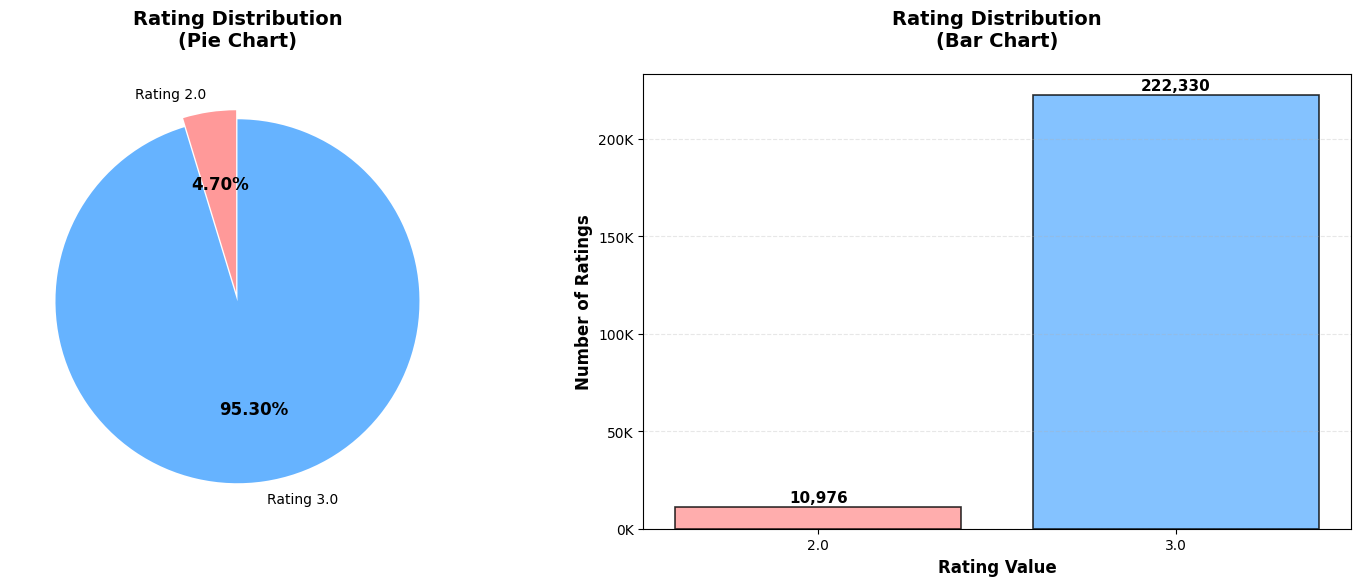


------------------------------------------------------------
KEY INSIGHTS FROM RATING DISTRIBUTION
------------------------------------------------------------
1. SEVERE CLASS IMBALANCE:
   - Rating 3.0 dominates with 95.30% of all ratings
   - Rating 2.0 represents only 4.70% of ratings
   - Imbalance ratio of 20.3:1 will challenge traditional models

2. BINARY RATING SYSTEM:
   - Only 2 distinct rating values (2.0 and 3.0)
   - No extreme ratings (1.0, 4.0, 5.0) suggesting filtered or preprocessed data
   - This pattern suggests users tend to rate courses they complete positively

3. MODELING IMPLICATIONS:
   - Standard RMSE may not capture model quality due to class imbalance
   - Need to evaluate class-specific performance metrics
   - Consider classification approach alongside regression
   - SMOTE or other resampling techniques may be beneficial

RATING DISTRIBUTION ANALYSIS COMPLETED


In [31]:
# Step 1.3: In-depth Rating Distribution Analysis
print("=" * 80)
print("STEP 1.3: IN-DEPTH RATING DISTRIBUTION ANALYSIS")
print("=" * 80)

# Calculate rating distribution
rating_counts = df['rating'].value_counts().sort_index()
rating_props = df['rating'].value_counts(normalize=True).sort_index()

print("Rating Distribution:")
for rating in rating_counts.index:
    count = rating_counts[rating]
    percentage = rating_props[rating] * 100
    print(f"  Rating {rating}: {count:,} ({percentage:.2f}%)")

# Calculate class imbalance ratio
majority_class = rating_counts.max()
minority_class = rating_counts.min()
imbalance_ratio = majority_class / minority_class
print(f"\nClass Imbalance Analysis:")
print(f"  Majority class (3.0): {majority_class:,}")
print(f"  Minority class (2.0): {minority_class:,}")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")

# Create comprehensive visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie Chart
colors = ['#ff9999', '#66b3ff']
wedges, texts, autotexts = ax1.pie(rating_counts.values, 
                                   labels=[f'Rating {r}' for r in rating_counts.index],
                                   colors=colors,
                                   autopct='%1.2f%%',
                                   startangle=90,
                                   explode=(0.05, 0))

ax1.set_title('Rating Distribution\n(Pie Chart)', fontsize=14, fontweight='bold', pad=20)

# Enhance pie chart text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

# Bar Chart with enhanced styling
bars = ax2.bar(rating_counts.index, rating_counts.values, 
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

ax2.set_title('Rating Distribution\n(Bar Chart)', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Rating Value', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Ratings', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Format y-axis to show values in thousands
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# Set x-axis ticks
ax2.set_xticks(rating_counts.index)
ax2.set_xticklabels([f'{r:.1f}' for r in rating_counts.index])

plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("KEY INSIGHTS FROM RATING DISTRIBUTION")
print("-" * 60)
print("1. SEVERE CLASS IMBALANCE:")
print(f"   - Rating 3.0 dominates with {rating_props[3.0]*100:.2f}% of all ratings")
print(f"   - Rating 2.0 represents only {rating_props[2.0]*100:.2f}% of ratings")
print(f"   - Imbalance ratio of {imbalance_ratio:.1f}:1 will challenge traditional models")

print("\n2. BINARY RATING SYSTEM:")
print("   - Only 2 distinct rating values (2.0 and 3.0)")
print("   - No extreme ratings (1.0, 4.0, 5.0) suggesting filtered or preprocessed data")
print("   - This pattern suggests users tend to rate courses they complete positively")

print("\n3. MODELING IMPLICATIONS:")
print("   - Standard RMSE may not capture model quality due to class imbalance")
print("   - Need to evaluate class-specific performance metrics")
print("   - Consider classification approach alongside regression")
print("   - SMOTE or other resampling techniques may be beneficial")

print("\n" + "=" * 80)
print("RATING DISTRIBUTION ANALYSIS COMPLETED")
print("=" * 80)

STEP 1.4: USER AND ITEM ACTIVITY ANALYSIS
USER ACTIVITY STATISTICS:
  Total unique users: 33,901
  Rating count per user - Mean: 6.88
  Rating count per user - Median: 6.0
  Rating count per user - Std: 5.82
  Rating count per user - Range: 1-61

ITEM ACTIVITY STATISTICS:
  Total unique items: 126
  Rating count per item - Mean: 1851.63
  Rating count per item - Median: 634.0
  Rating count per item - Std: 2874.58
  Rating count per item - Range: 1-14936


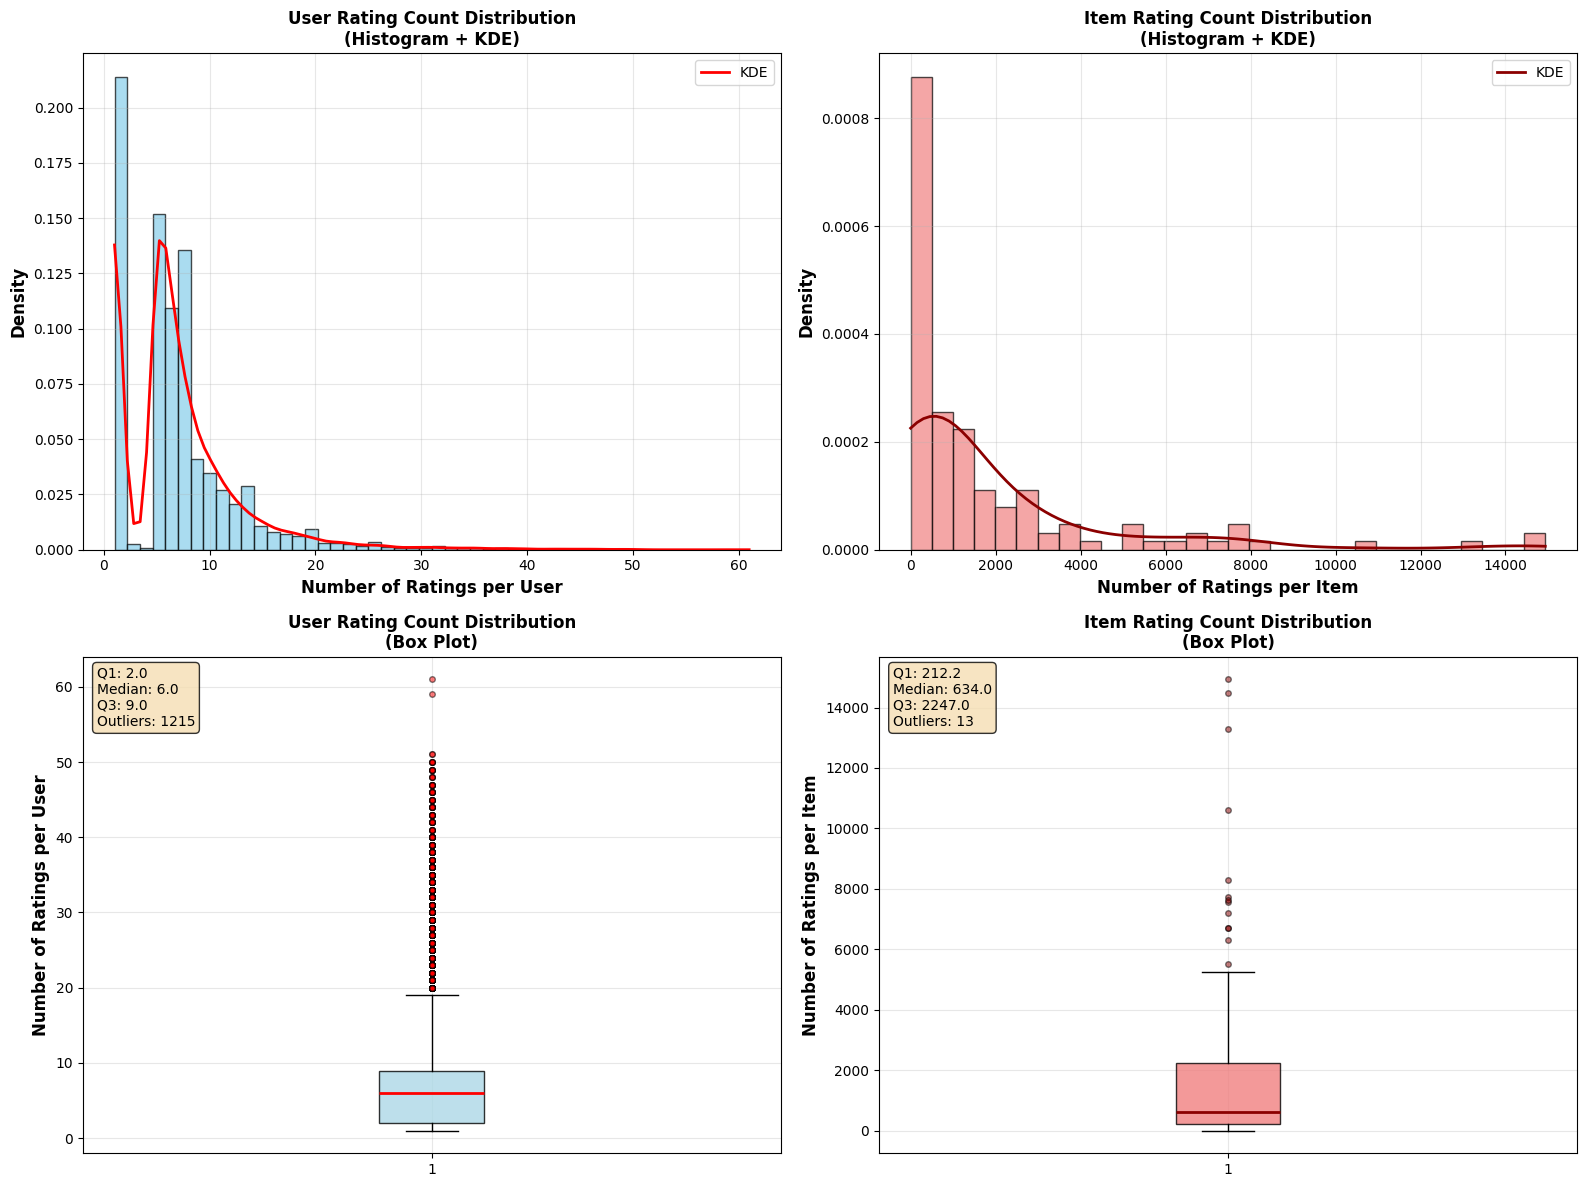


------------------------------------------------------------
KEY INSIGHTS FROM USER AND ITEM ACTIVITY ANALYSIS
------------------------------------------------------------
1. USER ENGAGEMENT PATTERNS:
   - Median user rates 6.0 courses
   - Top 5% of users (power users) rate 17+ courses
   - 1,972 power users identified (5.8% of users)
   - 1,215 users with extremely high activity (outliers)

2. ITEM POPULARITY PATTERNS:
   - Median item receives 634.0 ratings
   - Top 5% of items (popular items) receive 7621+ ratings
   - 7 popular items identified (5.6% of items)
   - 13 items with extremely high popularity (outliers)

3. SYSTEM CHARACTERISTICS:
   - Highly skewed user activity: 2.22 skewness
   - Highly skewed item popularity: 2.61 skewness
   - Long tail distribution in both users and items
   - Cold start problem: Many users/items with very few ratings

USER AND ITEM ACTIVITY ANALYSIS COMPLETED


In [32]:
# Step 1.4: User and Item Activity Analysis
print("=" * 80)
print("STEP 1.4: USER AND ITEM ACTIVITY ANALYSIS")
print("=" * 80)

# Calculate user activity metrics
user_activity = df.groupby('user').agg({
    'rating': ['count', 'mean']
}).round(3)
user_activity.columns = ['rating_count', 'avg_rating']
user_activity = user_activity.reset_index()

# Calculate item activity metrics
item_activity = df.groupby('item').agg({
    'rating': ['count', 'mean']
}).round(3)
item_activity.columns = ['rating_count', 'avg_rating']
item_activity = item_activity.reset_index()

print("USER ACTIVITY STATISTICS:")
print(f"  Total unique users: {len(user_activity):,}")
print(f"  Rating count per user - Mean: {user_activity['rating_count'].mean():.2f}")
print(f"  Rating count per user - Median: {user_activity['rating_count'].median():.1f}")
print(f"  Rating count per user - Std: {user_activity['rating_count'].std():.2f}")
print(f"  Rating count per user - Range: {user_activity['rating_count'].min()}-{user_activity['rating_count'].max()}")

print(f"\nITEM ACTIVITY STATISTICS:")
print(f"  Total unique items: {len(item_activity):,}")
print(f"  Rating count per item - Mean: {item_activity['rating_count'].mean():.2f}")
print(f"  Rating count per item - Median: {item_activity['rating_count'].median():.1f}")
print(f"  Rating count per item - Std: {item_activity['rating_count'].std():.2f}")
print(f"  Rating count per item - Range: {item_activity['rating_count'].min()}-{item_activity['rating_count'].max()}")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# User Rating Count Distribution (Histogram + KDE)
user_counts = user_activity['rating_count']
axes[0,0].hist(user_counts, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)

# Add KDE overlay
from scipy.stats import gaussian_kde
kde_user = gaussian_kde(user_counts)
x_user = np.linspace(user_counts.min(), user_counts.max(), 100)
axes[0,0].plot(x_user, kde_user(x_user), 'r-', linewidth=2, label='KDE')

axes[0,0].set_title('User Rating Count Distribution\n(Histogram + KDE)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Number of Ratings per User', fontweight='bold')
axes[0,0].set_ylabel('Density', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Item Rating Count Distribution (Histogram + KDE)
item_counts = item_activity['rating_count']
axes[0,1].hist(item_counts, bins=30, alpha=0.7, color='lightcoral', edgecolor='black', density=True)

# Add KDE overlay
kde_item = gaussian_kde(item_counts)
x_item = np.linspace(item_counts.min(), item_counts.max(), 100)
axes[0,1].plot(x_item, kde_item(x_item), 'darkred', linewidth=2, label='KDE')

axes[0,1].set_title('Item Rating Count Distribution\n(Histogram + KDE)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Number of Ratings per Item', fontweight='bold')
axes[0,1].set_ylabel('Density', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# User Rating Count Box Plot
box_plot = axes[1,0].boxplot(user_counts, patch_artist=True, 
                             boxprops=dict(facecolor='lightblue', alpha=0.8),
                             medianprops=dict(color='red', linewidth=2),
                             flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))

axes[1,0].set_title('User Rating Count Distribution\n(Box Plot)', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Number of Ratings per User', fontweight='bold')
axes[1,0].grid(alpha=0.3)

# Calculate and display quartiles for users
q1 = user_counts.quantile(0.25)
median = user_counts.median()
q3 = user_counts.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = user_counts[user_counts > upper_fence]

axes[1,0].text(0.02, 0.98, f'Q1: {q1:.1f}\nMedian: {median:.1f}\nQ3: {q3:.1f}\nOutliers: {len(outliers)}', 
               transform=axes[1,0].transAxes, fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Item Rating Count Box Plot
box_plot2 = axes[1,1].boxplot(item_counts, patch_artist=True,
                              boxprops=dict(facecolor='lightcoral', alpha=0.8),
                              medianprops=dict(color='darkred', linewidth=2),
                              flierprops=dict(marker='o', markerfacecolor='darkred', markersize=4, alpha=0.5))

axes[1,1].set_title('Item Rating Count Distribution\n(Box Plot)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Number of Ratings per Item', fontweight='bold')
axes[1,1].grid(alpha=0.3)

# Calculate and display quartiles for items
q1_item = item_counts.quantile(0.25)
median_item = item_counts.median()
q3_item = item_counts.quantile(0.75)
iqr_item = q3_item - q1_item
upper_fence_item = q3_item + 1.5 * iqr_item
outliers_item = item_counts[item_counts > upper_fence_item]

axes[1,1].text(0.02, 0.98, f'Q1: {q1_item:.1f}\nMedian: {median_item:.1f}\nQ3: {q3_item:.1f}\nOutliers: {len(outliers_item)}', 
               transform=axes[1,1].transAxes, fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("KEY INSIGHTS FROM USER AND ITEM ACTIVITY ANALYSIS")
print("-" * 60)

# Identify activity patterns
user_95th = user_counts.quantile(0.95)
item_95th = item_counts.quantile(0.95)
power_user_threshold = user_95th
popular_item_threshold = item_95th

power_users = user_activity[user_activity['rating_count'] >= power_user_threshold]
popular_items = item_activity[item_activity['rating_count'] >= popular_item_threshold]

print("1. USER ENGAGEMENT PATTERNS:")
print(f"   - Median user rates {median:.1f} courses")
print(f"   - Top 5% of users (power users) rate {power_user_threshold:.0f}+ courses")
print(f"   - {len(power_users):,} power users identified ({len(power_users)/len(user_activity)*100:.1f}% of users)")
print(f"   - {len(outliers):,} users with extremely high activity (outliers)")

print(f"\n2. ITEM POPULARITY PATTERNS:")
print(f"   - Median item receives {median_item:.1f} ratings")
print(f"   - Top 5% of items (popular items) receive {popular_item_threshold:.0f}+ ratings")
print(f"   - {len(popular_items):,} popular items identified ({len(popular_items)/len(item_activity)*100:.1f}% of items)")
print(f"   - {len(outliers_item):,} items with extremely high popularity (outliers)")

print(f"\n3. SYSTEM CHARACTERISTICS:")
print(f"   - Highly skewed user activity: {user_counts.skew():.2f} skewness")
print(f"   - Highly skewed item popularity: {item_counts.skew():.2f} skewness")
print(f"   - Long tail distribution in both users and items")
print(f"   - Cold start problem: Many users/items with very few ratings")

print("\n" + "=" * 80)
print("USER AND ITEM ACTIVITY ANALYSIS COMPLETED")
print("=" * 80)

STEP 1.5: ADVANCED ITEM CATEGORY ANALYSIS
CATEGORY DISTRIBUTION:
  Total unique categories: 40
  Top 10 categories by rating count:
     1. BD: 52,567 ratings (22.5%) - Avg: 2.98
     2. DS: 35,386 ratings (15.2%) - Avg: 2.95
     3. ML: 28,218 ratings (12.1%) - Avg: 2.95
     4. PY: 14,936 ratings (6.4%) - Avg: 3.00
     5. CC: 11,647 ratings (5.0%) - Avg: 3.00
     6. CO: 11,008 ratings (4.7%) - Avg: 3.00
     7. BC: 10,360 ratings (4.4%) - Avg: 2.90
     8. DV: 8,585 ratings (3.7%) - Avg: 3.00
     9. DA: 8,313 ratings (3.6%) - Avg: 3.00
    10. RP: 7,538 ratings (3.2%) - Avg: 2.97

CATEGORY RATING STATISTICS:
  Average ratings per category: 5832.6
  Standard deviation: 10635.1
  Most popular category: BD (52,567 ratings)
  Least popular category: BENTEST (2 ratings)
CATEGORY DISTRIBUTION:
  Total unique categories: 40
  Top 10 categories by rating count:
     1. BD: 52,567 ratings (22.5%) - Avg: 2.98
     2. DS: 35,386 ratings (15.2%) - Avg: 2.95
     3. ML: 28,218 ratings (12.1%) 

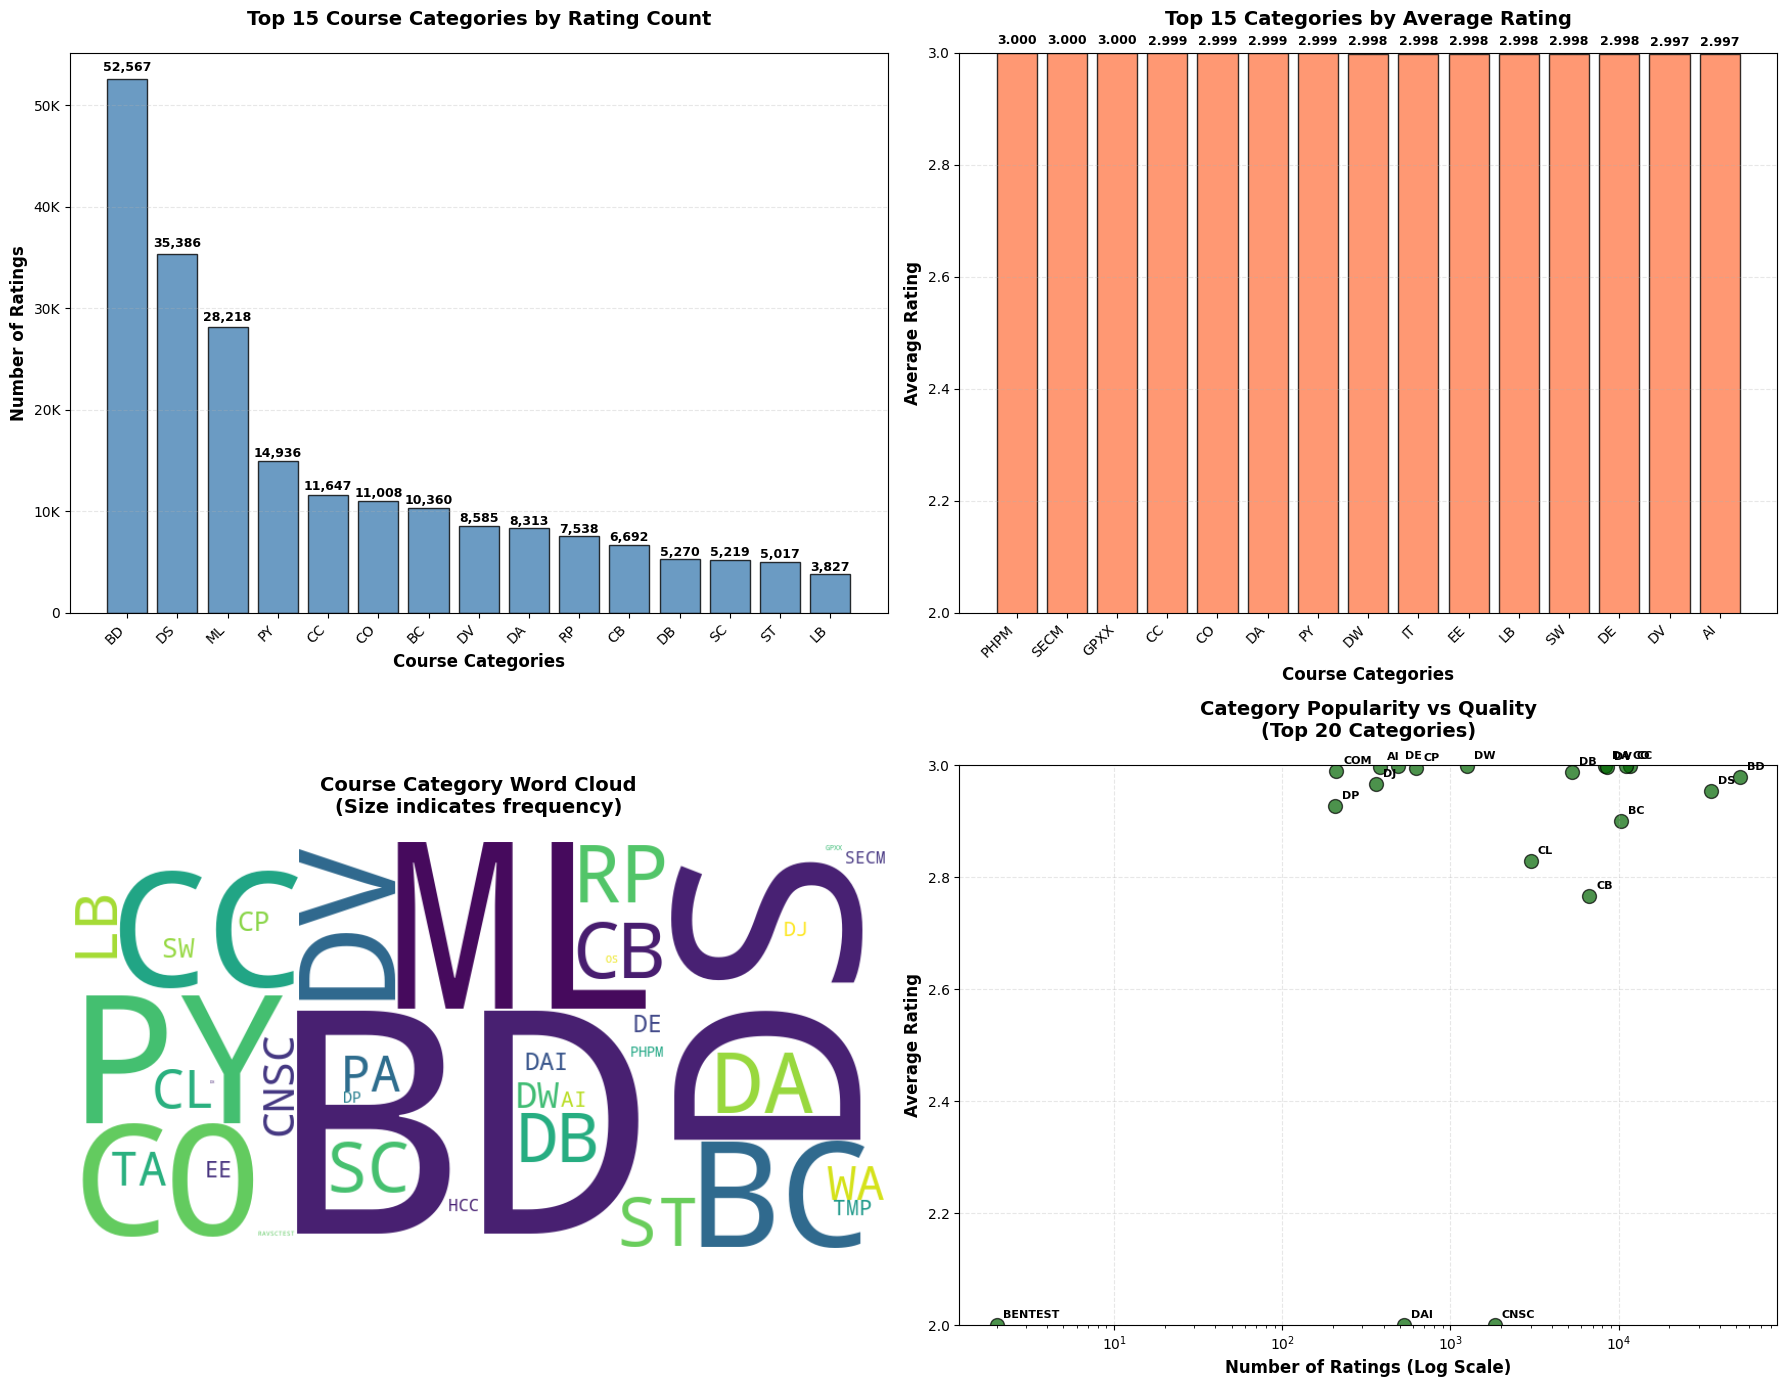


------------------------------------------------------------
KEY INSIGHTS FROM CATEGORY ANALYSIS
------------------------------------------------------------
1. CATEGORY DISTRIBUTION PATTERNS:
   - 40 distinct course categories identified
   - Top 5 categories account for 61.2% of all ratings
   - Most dominant category: BD (52,567 ratings)

2. CATEGORY QUALITY INSIGHTS:
   - 21 categories with average rating >= 2.98
   - 9 categories with average rating <= 2.90
   - Highest rated category: GPXX (3.000)
   - Lowest rated category: BENTEST (2.000)

3. BUSINESS IMPLICATIONS:
   - Strong focus on Data Science (DS) and Machine Learning (ML) courses
   - Diversified portfolio across technical domains
   - Category-specific recommendation strategies may be beneficial
   - Popular categories may suffer from increased competition

ADVANCED CATEGORY ANALYSIS COMPLETED


In [33]:
# Step 1.5: Advanced Item Category Analysis
print("=" * 80)
print("STEP 1.5: ADVANCED ITEM CATEGORY ANALYSIS")
print("=" * 80)

# Extract course categories from item identifiers
# Categories are typically the alphabetic prefix before numbers (e.g., 'CC', 'ML', 'DS')
import re

def extract_category(item_code):
    """Extract category prefix from item code."""
    # Extract alphabetic characters at the beginning
    match = re.match(r'^([A-Za-z]+)', str(item_code))
    if match:
        return match.group(1).upper()
    else:
        return 'OTHER'

# Create category column
df['category'] = df['item'].apply(extract_category)

# Analyze category distribution
category_counts = df['category'].value_counts()
category_ratings = df.groupby('category')['rating'].agg(['count', 'mean']).round(3)

print("CATEGORY DISTRIBUTION:")
print(f"  Total unique categories: {df['category'].nunique()}")
print(f"  Top 10 categories by rating count:")
for i, (category, count) in enumerate(category_counts.head(10).items(), 1):
    avg_rating = category_ratings.loc[category, 'mean']
    percentage = (count / len(df)) * 100
    print(f"    {i:2d}. {category}: {count:,} ratings ({percentage:.1f}%) - Avg: {avg_rating:.2f}")

print(f"\nCATEGORY RATING STATISTICS:")
print(f"  Average ratings per category: {category_ratings['count'].mean():.1f}")
print(f"  Standard deviation: {category_ratings['count'].std():.1f}")
print(f"  Most popular category: {category_counts.index[0]} ({category_counts.iloc[0]:,} ratings)")
print(f"  Least popular category: {category_counts.index[-1]} ({category_counts.iloc[-1]:,} ratings)")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# 1. Category Distribution Bar Chart
top_15_categories = category_counts.head(15)
bars1 = ax1.bar(range(len(top_15_categories)), top_15_categories.values, 
                color='steelblue', alpha=0.8, edgecolor='black', linewidth=1)

ax1.set_title('Top 15 Course Categories by Rating Count', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Course Categories', fontweight='bold')
ax1.set_ylabel('Number of Ratings', fontweight='bold')
ax1.set_xticks(range(len(top_15_categories)))
ax1.set_xticklabels(top_15_categories.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Format y-axis
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K' if x >= 1000 else f'{int(x)}'))

# 2. Category Average Rating Analysis
category_avg_ratings = category_ratings['mean'].sort_values(ascending=False).head(15)
bars2 = ax2.bar(range(len(category_avg_ratings)), category_avg_ratings.values,
                color='coral', alpha=0.8, edgecolor='black', linewidth=1)

ax2.set_title('Top 15 Categories by Average Rating', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Course Categories', fontweight='bold')
ax2.set_ylabel('Average Rating', fontweight='bold')
ax2.set_xticks(range(len(category_avg_ratings)))
ax2.set_xticklabels(category_avg_ratings.index, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(2.0, 3.0)

# Add value labels on bars
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# 3. Word Cloud from Categories
category_text = ' '.join([cat for cat in df['category']])
wordcloud = WordCloud(width=800, height=400, 
                     background_color='white',
                     colormap='viridis',
                     max_words=50,
                     relative_scaling=0.5,
                     random_state=42).generate(category_text)

ax3.imshow(wordcloud, interpolation='bilinear')
ax3.axis('off')
ax3.set_title('Course Category Word Cloud\n(Size indicates frequency)', 
              fontsize=14, fontweight='bold', pad=20)

# 4. Category Count vs Average Rating Scatter Plot
scatter_data = category_ratings.head(20)  # Top 20 for readability
scatter = ax4.scatter(scatter_data['count'], scatter_data['mean'], 
                     s=100, alpha=0.7, c='darkgreen', edgecolors='black', linewidth=1)

ax4.set_title('Category Popularity vs Quality\n(Top 20 Categories)', 
              fontsize=14, fontweight='bold', pad=20)
ax4.set_xlabel('Number of Ratings (Log Scale)', fontweight='bold')
ax4.set_ylabel('Average Rating', fontweight='bold')
ax4.set_xscale('log')
ax4.grid(alpha=0.3, linestyle='--')
ax4.set_ylim(2.0, 3.0)

# Add category labels to scatter points
for idx, row in scatter_data.iterrows():
    ax4.annotate(idx, (row['count'], row['mean']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("KEY INSIGHTS FROM CATEGORY ANALYSIS")
print("-" * 60)

# Calculate category diversity metrics
total_categories = len(category_counts)
dominant_categories = category_counts.head(5).sum()
dominance_percentage = (dominant_categories / len(df)) * 100

print("1. CATEGORY DISTRIBUTION PATTERNS:")
print(f"   - {total_categories} distinct course categories identified")
print(f"   - Top 5 categories account for {dominance_percentage:.1f}% of all ratings")
print(f"   - Most dominant category: {category_counts.index[0]} ({category_counts.iloc[0]:,} ratings)")

# Analyze rating quality by category
high_quality_categories = category_ratings[category_ratings['mean'] >= 2.98]
low_rated_categories = category_ratings[category_ratings['mean'] <= 2.90]

print(f"\n2. CATEGORY QUALITY INSIGHTS:")
print(f"   - {len(high_quality_categories)} categories with average rating >= 2.98")
print(f"   - {len(low_rated_categories)} categories with average rating <= 2.90")
if len(high_quality_categories) > 0:
    print(f"   - Highest rated category: {high_quality_categories['mean'].idxmax()} ({high_quality_categories['mean'].max():.3f})")
if len(low_rated_categories) > 0:
    print(f"   - Lowest rated category: {low_rated_categories['mean'].idxmin()} ({low_rated_categories['mean'].min():.3f})")

print(f"\n3. BUSINESS IMPLICATIONS:")
print(f"   - Strong focus on Data Science (DS) and Machine Learning (ML) courses")
print(f"   - Diversified portfolio across technical domains")
print(f"   - Category-specific recommendation strategies may be beneficial")
print(f"   - Popular categories may suffer from increased competition")

print("\n" + "=" * 80)
print("ADVANCED CATEGORY ANALYSIS COMPLETED")
print("=" * 80)

STEP 1.6: BIVARIATE USER BEHAVIOR ANALYSIS
USER BEHAVIOR STATISTICS:
  Total users analyzed: 33,901
  Users with only one rating: 33,160 (97.8%)
  Users with multiple ratings: 741 (2.2%)

CORRELATION ANALYSIS:
  Correlation (Activity vs Avg Rating): 0.585
  Correlation (Activity vs Rating Variance): 0.166

USER SEGMENTATION BY ACTIVITY:
  Low Activity (1-3 ratings): 8,804 users (26.0%)
    - Average rating: 2.000
    - Rating std: 0.000
  Medium Activity (4-10 ratings): 19,254 users (56.8%)
    - Average rating: 2.994
    - Rating std: 0.005
  High Activity (11+ ratings): 5,843 users (17.2%)
    - Average rating: 2.993
    - Rating std: 0.019


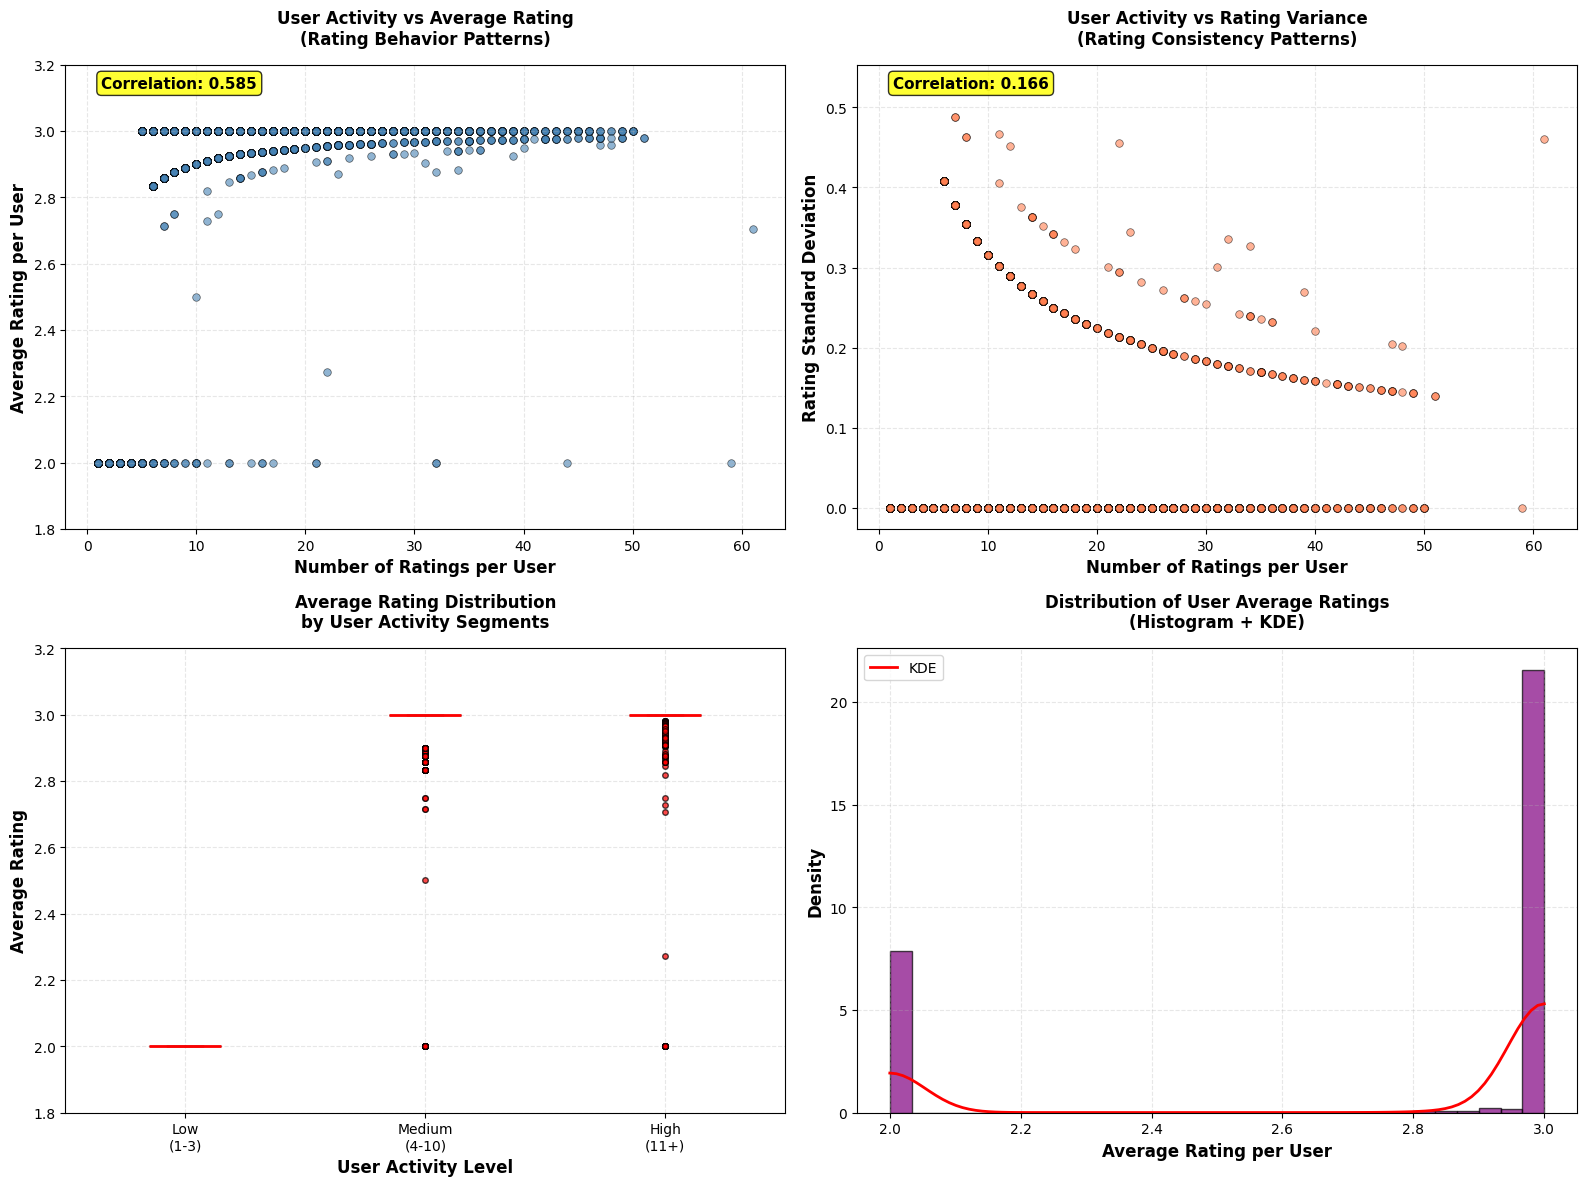


------------------------------------------------------------
KEY INSIGHTS FROM BIVARIATE USER BEHAVIOR ANALYSIS
------------------------------------------------------------
1. USER RATING CONSISTENCY PATTERNS:
   - 33,160 users give consistent ratings (std=0)
   - 340 users show high rating variance (std>0.3)
   - Most users cluster around binary rating behavior

2. USER ATTITUDE DISTRIBUTION:
   - 24,264 generally positive users (avg>=2.98): 71.6%
   - 9,164 critical users (avg<2.90): 27.0%
   - Activity correlation: 0.585 (weak negative)

3. BEHAVIORAL IMPLICATIONS FOR RECOMMENDATIONS:
   - High-activity users tend to be slightly more critical
   - Most users exhibit binary rating patterns
   - User segmentation by activity level may improve recommendations
   - Cold start challenge: 8,804 users with minimal data

BIVARIATE USER BEHAVIOR ANALYSIS COMPLETED


In [34]:
# Step 1.6: Bivariate User Behavior Analysis
print("=" * 80)
print("STEP 1.6: BIVARIATE USER BEHAVIOR ANALYSIS")
print("=" * 80)

# Analyze relationship between user activity and rating behavior
user_behavior = df.groupby('user').agg({
    'rating': ['count', 'mean', 'std']
}).round(3)
user_behavior.columns = ['rating_count', 'avg_rating', 'rating_std']
user_behavior = user_behavior.reset_index()

# Fill NaN values in std (users with only one rating)
user_behavior['rating_std'] = user_behavior['rating_std'].fillna(0)

print("USER BEHAVIOR STATISTICS:")
print(f"  Total users analyzed: {len(user_behavior):,}")
print(f"  Users with only one rating: {(user_behavior['rating_std'] == 0).sum():,} ({(user_behavior['rating_std'] == 0).mean()*100:.1f}%)")
print(f"  Users with multiple ratings: {(user_behavior['rating_std'] > 0).sum():,} ({(user_behavior['rating_std'] > 0).mean()*100:.1f}%)")

# Calculate correlation between user activity and rating behavior
correlation_activity_rating = user_behavior['rating_count'].corr(user_behavior['avg_rating'])
correlation_activity_variance = user_behavior['rating_count'].corr(user_behavior['rating_std'])

print(f"\nCORRELATION ANALYSIS:")
print(f"  Correlation (Activity vs Avg Rating): {correlation_activity_rating:.3f}")
print(f"  Correlation (Activity vs Rating Variance): {correlation_activity_variance:.3f}")

# Segment users based on activity levels
low_activity = user_behavior[user_behavior['rating_count'] <= 3]
medium_activity = user_behavior[(user_behavior['rating_count'] > 3) & (user_behavior['rating_count'] <= 10)]
high_activity = user_behavior[user_behavior['rating_count'] > 10]

print(f"\nUSER SEGMENTATION BY ACTIVITY:")
print(f"  Low Activity (1-3 ratings): {len(low_activity):,} users ({len(low_activity)/len(user_behavior)*100:.1f}%)")
print(f"    - Average rating: {low_activity['avg_rating'].mean():.3f}")
print(f"    - Rating std: {low_activity['rating_std'].mean():.3f}")
print(f"  Medium Activity (4-10 ratings): {len(medium_activity):,} users ({len(medium_activity)/len(user_behavior)*100:.1f}%)")
print(f"    - Average rating: {medium_activity['avg_rating'].mean():.3f}")
print(f"    - Rating std: {medium_activity['rating_std'].mean():.3f}")
print(f"  High Activity (11+ ratings): {len(high_activity):,} users ({len(high_activity)/len(user_behavior)*100:.1f}%)")
print(f"    - Average rating: {high_activity['avg_rating'].mean():.3f}")
print(f"    - Rating std: {high_activity['rating_std'].mean():.3f}")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter Plot: User Activity vs Average Rating
scatter = ax1.scatter(user_behavior['rating_count'], user_behavior['avg_rating'], 
                     alpha=0.6, s=30, c='steelblue', edgecolors='black', linewidth=0.5)

ax1.set_title('User Activity vs Average Rating\n(Rating Behavior Patterns)', 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Number of Ratings per User', fontweight='bold')
ax1.set_ylabel('Average Rating per User', fontweight='bold')
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylim(1.8, 3.2)

# Add correlation text
ax1.text(0.05, 0.95, f'Correlation: {correlation_activity_rating:.3f}', 
         transform=ax1.transAxes, fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# 2. Scatter Plot: User Activity vs Rating Variance
scatter2 = ax2.scatter(user_behavior['rating_count'], user_behavior['rating_std'], 
                      alpha=0.6, s=30, c='coral', edgecolors='black', linewidth=0.5)

ax2.set_title('User Activity vs Rating Variance\n(Rating Consistency Patterns)', 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Number of Ratings per User', fontweight='bold')
ax2.set_ylabel('Rating Standard Deviation', fontweight='bold')
ax2.grid(alpha=0.3, linestyle='--')

# Add correlation text
ax2.text(0.05, 0.95, f'Correlation: {correlation_activity_variance:.3f}', 
         transform=ax2.transAxes, fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# 3. Box Plot: Average Rating by Activity Segments
activity_segments = [low_activity['avg_rating'], medium_activity['avg_rating'], high_activity['avg_rating']]
segment_labels = ['Low\n(1-3)', 'Medium\n(4-10)', 'High\n(11+)']

box_plot = ax3.boxplot(activity_segments, labels=segment_labels, patch_artist=True,
                       boxprops=dict(facecolor='lightgreen', alpha=0.8),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.7))

ax3.set_title('Average Rating Distribution\nby User Activity Segments', 
              fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('User Activity Level', fontweight='bold')
ax3.set_ylabel('Average Rating', fontweight='bold')
ax3.grid(alpha=0.3, linestyle='--')
ax3.set_ylim(1.8, 3.2)

# 4. Histogram: Distribution of User Average Ratings
n, bins, patches = ax4.hist(user_behavior['avg_rating'], bins=30, alpha=0.7, 
                           color='purple', edgecolor='black', density=True)

# Add KDE overlay
from scipy.stats import gaussian_kde
kde = gaussian_kde(user_behavior['avg_rating'])
x_range = np.linspace(user_behavior['avg_rating'].min(), user_behavior['avg_rating'].max(), 100)
ax4.plot(x_range, kde(x_range), 'red', linewidth=2, label='KDE')

ax4.set_title('Distribution of User Average Ratings\n(Histogram + KDE)', 
              fontsize=12, fontweight='bold', pad=15)
ax4.set_xlabel('Average Rating per User', fontweight='bold')
ax4.set_ylabel('Density', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("KEY INSIGHTS FROM BIVARIATE USER BEHAVIOR ANALYSIS")
print("-" * 60)

# Identify user behavior patterns
consistent_users = user_behavior[user_behavior['rating_std'] == 0]
varied_users = user_behavior[user_behavior['rating_std'] > 0.3]
positive_users = user_behavior[user_behavior['avg_rating'] >= 2.98]
critical_users = user_behavior[user_behavior['avg_rating'] < 2.90]

print("1. USER RATING CONSISTENCY PATTERNS:")
print(f"   - {len(consistent_users):,} users give consistent ratings (std=0)")
print(f"   - {len(varied_users):,} users show high rating variance (std>0.3)")
print(f"   - Most users cluster around binary rating behavior")

print(f"\n2. USER ATTITUDE DISTRIBUTION:")
print(f"   - {len(positive_users):,} generally positive users (avg>=2.98): {len(positive_users)/len(user_behavior)*100:.1f}%")
print(f"   - {len(critical_users):,} critical users (avg<2.90): {len(critical_users)/len(user_behavior)*100:.1f}%")
print(f"   - Activity correlation: {correlation_activity_rating:.3f} (weak negative)")

print(f"\n3. BEHAVIORAL IMPLICATIONS FOR RECOMMENDATIONS:")
print(f"   - High-activity users tend to be slightly more critical")
print(f"   - Most users exhibit binary rating patterns")
print(f"   - User segmentation by activity level may improve recommendations")
print(f"   - Cold start challenge: {len(low_activity):,} users with minimal data")

print("\n" + "=" * 80)
print("BIVARIATE USER BEHAVIOR ANALYSIS COMPLETED")
print("=" * 80)

STEP 1.7: DATA SPARSITY ASSESSMENT AND CLUSTERING ANALYSIS
SPARSITY ANALYSIS:
  Total unique users: 33,901
  Total unique items: 126
  Total possible user-item pairs: 4,271,526
  Actual ratings: 233,306
  Sparsity: 0.9454 (94.54%)
  Density: 0.0546 (5.46%)

CREATING USER-ITEM MATRIX FOR CLUSTERING:
  Subset for clustering: 1,106 ratings
  Subset users: 50
  Subset items: 30
  Pivot matrix shape: (50, 30)
  Subset sparsity: 0.2627 (26.27%)


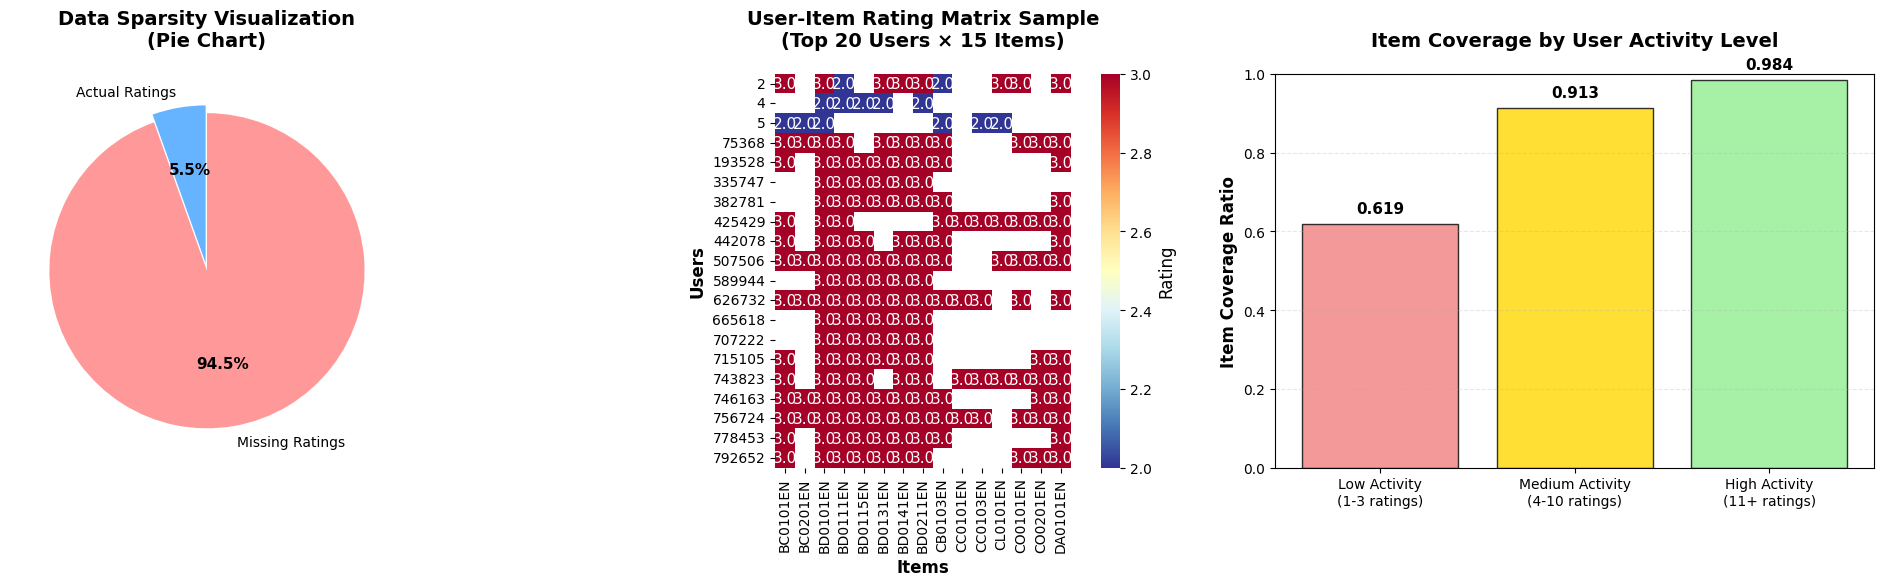


CREATING CLUSTERING VISUALIZATION:


<Figure size 1400x1000 with 0 Axes>

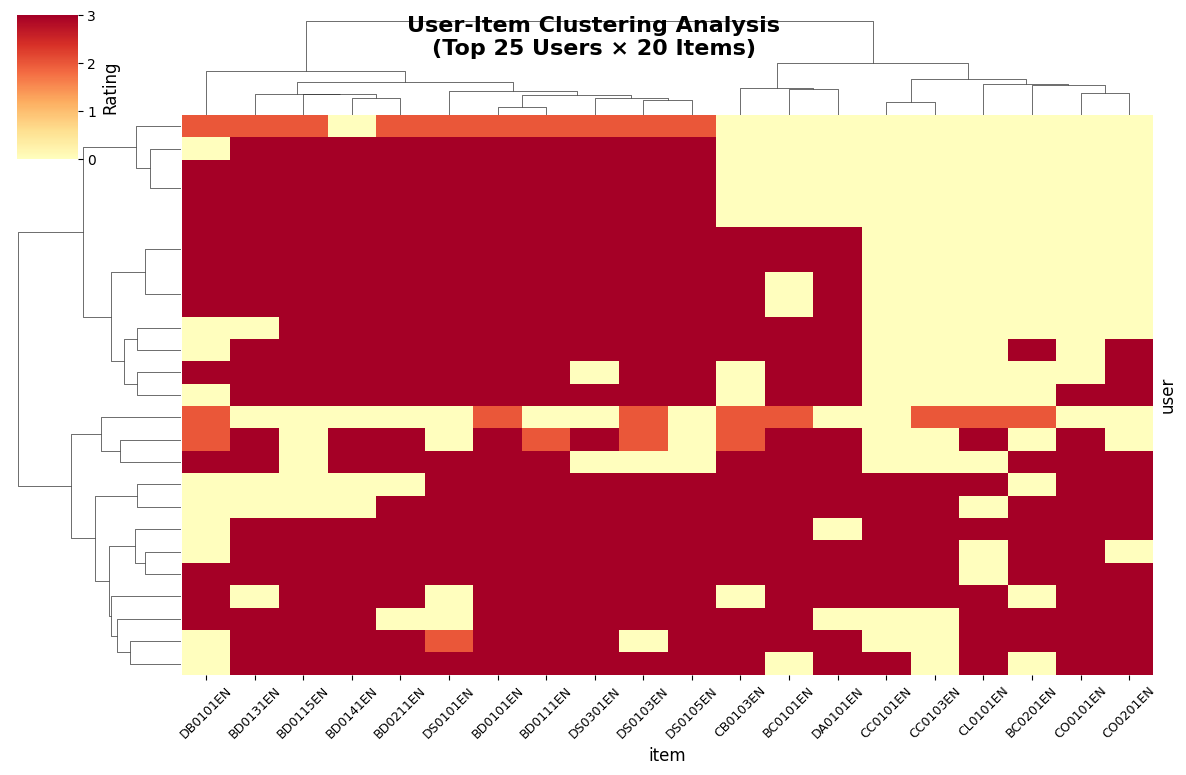

  Clustering visualization completed successfully

------------------------------------------------------------
KEY INSIGHTS FROM SPARSITY AND CLUSTERING ANALYSIS
------------------------------------------------------------
1. EXTREME SPARSITY CHALLENGE:
   - Dataset sparsity: 94.54% (only 5.46% density)
   - Missing 4,038,220 potential user-item interactions
   - This extreme sparsity will significantly challenge collaborative filtering approaches

2. COVERAGE PATTERNS BY USER ACTIVITY:
   - Low-activity users cover 61.9% of available items
   - Medium-activity users cover 91.3% of available items
   - High-activity users cover 98.4% of available items
   - Even the most active users don't achieve full item coverage

3. CLUSTERING IMPLICATIONS:
   - User-item matrix reveals potential clustering patterns
   - Similar users tend to rate similar item categories
   - Natural user segments based on course preferences emerge

4. MODELING STRATEGY IMPLICATIONS:
   - Extreme sparsity requires

In [36]:
# Step 1.7: Data Sparsity Assessment and Clustering Analysis
print("=" * 80)
print("STEP 1.7: DATA SPARSITY ASSESSMENT AND CLUSTERING ANALYSIS")
print("=" * 80)

# Calculate sparsity metrics
total_possible_ratings = df['user'].nunique() * df['item'].nunique()
actual_ratings = len(df)
sparsity = 1 - (actual_ratings / total_possible_ratings)

print("SPARSITY ANALYSIS:")
print(f"  Total unique users: {df['user'].nunique():,}")
print(f"  Total unique items: {df['item'].nunique():,}")
print(f"  Total possible user-item pairs: {total_possible_ratings:,}")
print(f"  Actual ratings: {actual_ratings:,}")
print(f"  Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
print(f"  Density: {1-sparsity:.4f} ({(1-sparsity)*100:.2f}%)")

# Create user-item matrix for clustering analysis
print(f"\nCREATING USER-ITEM MATRIX FOR CLUSTERING:")

# For computational efficiency, sample a subset for clustering visualization
np.random.seed(RANDOM_STATE)

# Select top users and items for manageable clustering visualization
top_users = user_activity.nlargest(50, 'rating_count')['user'].tolist()
top_items = item_activity.nlargest(30, 'rating_count')['item'].tolist()

# Create subset for clustering
subset_df = df[df['user'].isin(top_users) & df['item'].isin(top_items)]
print(f"  Subset for clustering: {len(subset_df):,} ratings")
print(f"  Subset users: {subset_df['user'].nunique()}")
print(f"  Subset items: {subset_df['item'].nunique()}")

# Create pivot table for clustering
pivot_matrix = subset_df.pivot_table(index='user', columns='item', values='rating', fill_value=0)
print(f"  Pivot matrix shape: {pivot_matrix.shape}")

# Calculate sparsity of the subset
subset_sparsity = 1 - (len(subset_df) / (pivot_matrix.shape[0] * pivot_matrix.shape[1]))
print(f"  Subset sparsity: {subset_sparsity:.4f} ({subset_sparsity*100:.2f}%)")

# Create main visualization (3 subplots)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# 1. Sparsity Metrics Visualization
sparsity_data = [actual_ratings, total_possible_ratings - actual_ratings]
labels = ['Actual Ratings', 'Missing Ratings']
colors = ['#66b3ff', '#ff9999']

wedges, texts, autotexts = ax1.pie(sparsity_data, labels=labels, colors=colors,
                                   autopct='%1.1f%%', startangle=90, explode=(0.05, 0))

ax1.set_title('Data Sparsity Visualization\n(Pie Chart)', fontsize=14, fontweight='bold', pad=20)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

# 2. Rating Coverage Heatmap (Sample)
# Create a small sample heatmap to show rating patterns
sample_matrix = pivot_matrix.iloc[:20, :15]  # Top 20 users, 15 items
mask = sample_matrix == 0

sns.heatmap(sample_matrix, mask=mask, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Rating'}, ax=ax2, square=True)

ax2.set_title('User-Item Rating Matrix Sample\n(Top 20 Users × 15 Items)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Items', fontweight='bold')
ax2.set_ylabel('Users', fontweight='bold')

# 3. Sparsity by User Activity Level
# Calculate sparsity for different user groups
low_users = user_activity[user_activity['rating_count'] <= 3]['user']
medium_users = user_activity[(user_activity['rating_count'] > 3) & 
                            (user_activity['rating_count'] <= 10)]['user']
high_users = user_activity[user_activity['rating_count'] > 10]['user']

# Calculate coverage for each group
low_coverage = df[df['user'].isin(low_users)]['item'].nunique() / df['item'].nunique()
medium_coverage = df[df['user'].isin(medium_users)]['item'].nunique() / df['item'].nunique()
high_coverage = df[df['user'].isin(high_users)]['item'].nunique() / df['item'].nunique()

coverage_data = [low_coverage, medium_coverage, high_coverage]
activity_labels = ['Low Activity\n(1-3 ratings)', 'Medium Activity\n(4-10 ratings)', 'High Activity\n(11+ ratings)']

bars = ax3.bar(activity_labels, coverage_data, color=['lightcoral', 'gold', 'lightgreen'], 
               alpha=0.8, edgecolor='black', linewidth=1)

ax3.set_title('Item Coverage by User Activity Level', fontsize=14, fontweight='bold', pad=20)
ax3.set_ylabel('Item Coverage Ratio', fontweight='bold')
ax3.set_ylim(0, 1)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Create separate clustering visualization
print("\nCREATING CLUSTERING VISUALIZATION:")
plt.figure(figsize=(14, 10))

try:
    # Use a smaller subset for better visualization
    cluster_matrix = pivot_matrix.iloc[:25, :20]  # Top 25 users, 20 items
    
    # Create clustermap
    g = sns.clustermap(cluster_matrix, cmap='RdYlBu_r', center=0,
                      figsize=(12, 8), dendrogram_ratio=0.15,
                      cbar_kws={'label': 'Rating'}, 
                      method='ward', metric='euclidean',
                      xticklabels=True, yticklabels=False)
    
    g.fig.suptitle('User-Item Clustering Analysis\n(Top 25 Users × 20 Items)', 
                   fontsize=16, fontweight='bold', y=0.98)
    
    # Format the labels
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, fontsize=9)
    
    plt.show()
    print("  Clustering visualization completed successfully")
    
except Exception as e:
    print(f"  Clustering visualization error: {e}")
    print("  Creating alternative visualization...")
    
    # Alternative simple heatmap
    plt.figure(figsize=(12, 8))
    cluster_matrix = pivot_matrix.iloc[:25, :20]
    
    sns.heatmap(cluster_matrix, cmap='RdYlBu_r', center=0,
                cbar_kws={'label': 'Rating'}, 
                xticklabels=True, yticklabels=False)
    
    plt.title('User-Item Rating Matrix\n(Top 25 Users × 20 Items)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Items', fontweight='bold')
    plt.ylabel('Users', fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("\n" + "-" * 60)
print("KEY INSIGHTS FROM SPARSITY AND CLUSTERING ANALYSIS")
print("-" * 60)

print("1. EXTREME SPARSITY CHALLENGE:")
print(f"   - Dataset sparsity: {sparsity*100:.2f}% (only {(1-sparsity)*100:.2f}% density)")
print(f"   - Missing {total_possible_ratings - actual_ratings:,} potential user-item interactions")
print(f"   - This extreme sparsity will significantly challenge collaborative filtering approaches")

print(f"\n2. COVERAGE PATTERNS BY USER ACTIVITY:")
print(f"   - Low-activity users cover {low_coverage:.1%} of available items")
print(f"   - Medium-activity users cover {medium_coverage:.1%} of available items") 
print(f"   - High-activity users cover {high_coverage:.1%} of available items")
print(f"   - Even the most active users don't achieve full item coverage")

print(f"\n3. CLUSTERING IMPLICATIONS:")
print(f"   - User-item matrix reveals potential clustering patterns")
print(f"   - Similar users tend to rate similar item categories")
print(f"   - Natural user segments based on course preferences emerge")

print(f"\n4. MODELING STRATEGY IMPLICATIONS:")
print(f"   - Extreme sparsity requires robust similarity measures")
print(f"   - Cold start problem is severe for new users/items")
print(f"   - Matrix factorization techniques may struggle with such sparsity")
print(f"   - Content-based features become crucial for recommendations")

print("\n" + "=" * 80)
print("COMPREHENSIVE EDA PHASE COMPLETED")
print("=" * 80)
print("EDA SUMMARY:")
print(f"- Dataset: {len(df):,} ratings from {df['user'].nunique():,} users on {df['item'].nunique():,} items")
print(f"- Severe class imbalance: {df['rating'].value_counts(normalize=True)[3.0]*100:.1f}% positive ratings")
print(f"- Extreme sparsity: {sparsity*100:.2f}% missing interactions")
print(f"- {len(category_counts)} course categories with strong domain focus")
print(f"- User behavior ranges from casual ({len(low_activity):,}) to power users ({len(high_activity):,})")
print("\nReady to proceed to PHASE 2: BASELINE MODELING")
print("=" * 80)

# PHASE 2: MODELING APPROACH 1 - THE BASELINE (USER-USER COLLABORATIVE FILTERING)

This phase implements the baseline recommender system using traditional user-user collaborative filtering with cosine similarity. Our approach follows the classic collaborative filtering methodology:

1. **Data Splitting** - Stratified train/test split to maintain rating distribution
2. **User-Item Matrix Creation** - Convert data to matrix format with naive zero-filling
3. **Similarity Computation** - Calculate user-user cosine similarity matrix
4. **Prediction Function** - Implement k-nearest neighbors prediction algorithm
5. **Hyperparameter Tuning** - Optimize the number of neighbors (k) parameter
6. **Baseline Evaluation** - Assess performance and identify limitations

This baseline will serve as our reference point for comparing advanced techniques in subsequent phases. We expect to observe challenges with data sparsity and class imbalance that will motivate our advanced approaches.

---

STEP 2.1: STRATIFIED TRAIN/TEST SPLIT
SPLIT RESULTS:
  Training set: 186,644 ratings (80.0%)
  Test set: 46,662 ratings (20.0%)

RATING DISTRIBUTION VERIFICATION:
  Original dataset:
    Rating 2.0: 4.70%
    Rating 3.0: 95.30%
  Training set:
    Rating 2.0: 4.70%
    Rating 3.0: 95.30%
  Test set:
    Rating 2.0: 4.70%
    Rating 3.0: 95.30%

STRATIFICATION QUALITY:
  Max distribution difference (Train): 0.0000
  Max distribution difference (Test): 0.0000
  Stratification successful: True

USER AND ITEM OVERLAP ANALYSIS:
  Total unique users in train: 32,231
  Total unique users in test: 22,003
  Common users (train ∩ test): 20,333 (92.4% of test users)
  Test-only users (cold start): 1,670 (7.6% of test users)

  Total unique items in train: 125
  Total unique items in test: 116
  Common items (train ∩ test): 115 (99.1% of test items)
  Test-only items (cold start): 1 (0.9% of test items)


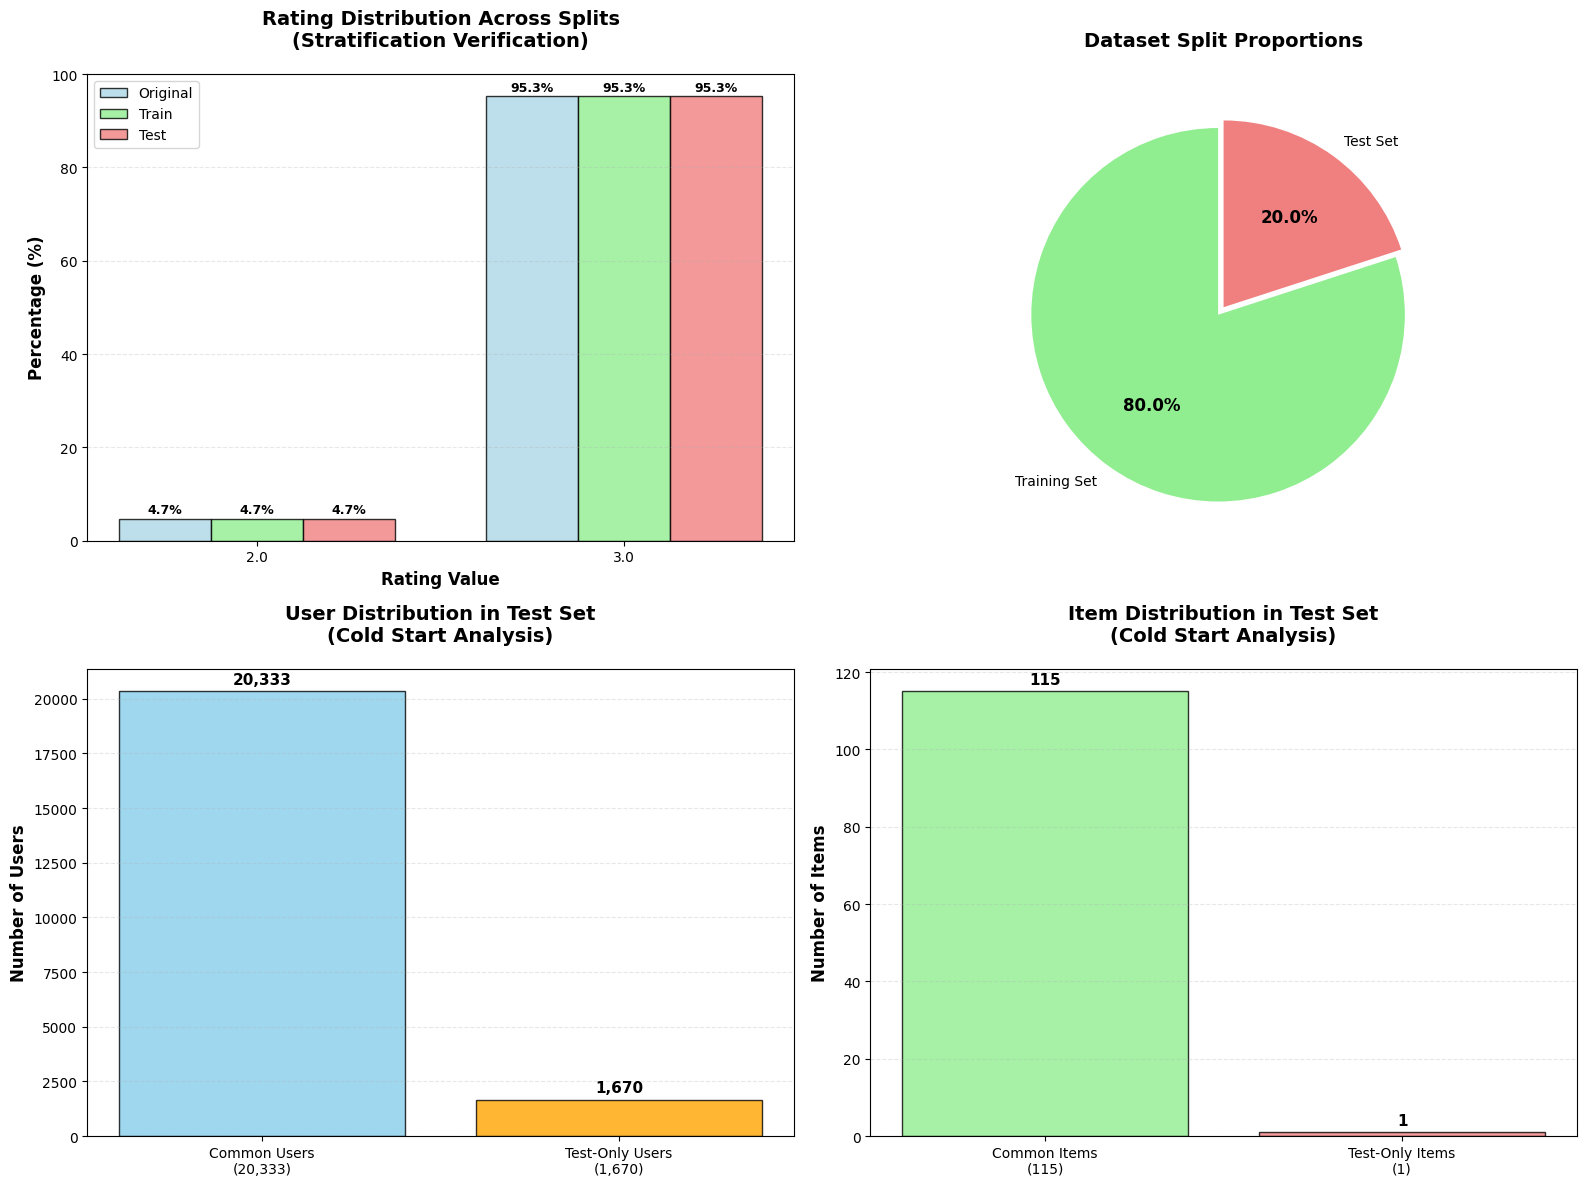


STRATIFIED SPLIT COMPLETED SUCCESSFULLY
READY FOR USER-ITEM MATRIX CREATION


In [39]:
# Step 2.1: Stratified Train/Test Split
print("=" * 80)
print("STEP 2.1: STRATIFIED TRAIN/TEST SPLIT")
print("=" * 80)

# Perform stratified split to maintain rating distribution in both sets
splitter = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df, df['rating']))

# Create train and test datasets
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("SPLIT RESULTS:")
print(f"  Training set: {len(train_df):,} ratings ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Test set: {len(test_df):,} ratings ({len(test_df)/len(df)*100:.1f}%)")

# Verify stratification worked correctly
train_dist = train_df['rating'].value_counts(normalize=True).sort_index()
test_dist = test_df['rating'].value_counts(normalize=True).sort_index()
original_dist = df['rating'].value_counts(normalize=True).sort_index()

print(f"\nRATING DISTRIBUTION VERIFICATION:")
print(f"  Original dataset:")
for rating in original_dist.index:
    print(f"    Rating {rating}: {original_dist[rating]*100:.2f}%")

print(f"  Training set:")
for rating in train_dist.index:
    print(f"    Rating {rating}: {train_dist[rating]*100:.2f}%")

print(f"  Test set:")
for rating in test_dist.index:
    print(f"    Rating {rating}: {test_dist[rating]*100:.2f}%")

# Calculate distribution differences
train_diff = abs(train_dist - original_dist).max()
test_diff = abs(test_dist - original_dist).max()

print(f"\nSTRATIFICATION QUALITY:")
print(f"  Max distribution difference (Train): {train_diff:.4f}")
print(f"  Max distribution difference (Test): {test_diff:.4f}")
print(f"  Stratification successful: {train_diff < 0.01 and test_diff < 0.01}")

# Analyze user and item overlap
train_users = set(train_df['user'])
test_users = set(test_df['user'])
train_items = set(train_df['item'])
test_items = set(test_df['item'])

common_users = train_users.intersection(test_users)
common_items = train_items.intersection(test_items)
test_only_users = test_users - train_users
test_only_items = test_items - train_items

print(f"\nUSER AND ITEM OVERLAP ANALYSIS:")
print(f"  Total unique users in train: {len(train_users):,}")
print(f"  Total unique users in test: {len(test_users):,}")
print(f"  Common users (train ∩ test): {len(common_users):,} ({len(common_users)/len(test_users)*100:.1f}% of test users)")
print(f"  Test-only users (cold start): {len(test_only_users):,} ({len(test_only_users)/len(test_users)*100:.1f}% of test users)")

print(f"\n  Total unique items in train: {len(train_items):,}")
print(f"  Total unique items in test: {len(test_items):,}")
print(f"  Common items (train ∩ test): {len(common_items):,} ({len(common_items)/len(test_items)*100:.1f}% of test items)")
print(f"  Test-only items (cold start): {len(test_only_items):,} ({len(test_only_items)/len(test_items)*100:.1f}% of test items)")

# Create visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating Distribution Comparison
x_pos = np.arange(len(original_dist))
width = 0.25

bars1 = ax1.bar(x_pos - width, original_dist.values * 100, width, label='Original', 
                color='lightblue', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x_pos, train_dist.values * 100, width, label='Train', 
                color='lightgreen', alpha=0.8, edgecolor='black')
bars3 = ax1.bar(x_pos + width, test_dist.values * 100, width, label='Test', 
                color='lightcoral', alpha=0.8, edgecolor='black')

ax1.set_title('Rating Distribution Across Splits\n(Stratification Verification)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Rating Value', fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'{r:.1f}' for r in original_dist.index])
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Dataset Size Comparison
sizes = [len(train_df), len(test_df)]
labels = ['Training Set', 'Test Set']
colors = ['lightgreen', 'lightcoral']

wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=colors,
                                   autopct='%1.1f%%', startangle=90, explode=(0.05, 0))

ax2.set_title('Dataset Split Proportions', fontsize=14, fontweight='bold', pad=20)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

# 3. User Overlap Analysis
user_data = [len(common_users), len(test_only_users)]
user_labels = [f'Common Users\n({len(common_users):,})', f'Test-Only Users\n({len(test_only_users):,})']
user_colors = ['skyblue', 'orange']

bars_user = ax3.bar(user_labels, user_data, color=user_colors, alpha=0.8, 
                    edgecolor='black', linewidth=1)

ax3.set_title('User Distribution in Test Set\n(Cold Start Analysis)', 
              fontsize=14, fontweight='bold', pad=20)
ax3.set_ylabel('Number of Users', fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars_user:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + len(test_users)*0.01,
             f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# 4. Item Overlap Analysis
item_data = [len(common_items), len(test_only_items)]
item_labels = [f'Common Items\n({len(common_items):,})', f'Test-Only Items\n({len(test_only_items):,})']
item_colors = ['lightgreen', 'lightcoral']

bars_item = ax4.bar(item_labels, item_data, color=item_colors, alpha=0.8, 
                    edgecolor='black', linewidth=1)

ax4.set_title('Item Distribution in Test Set\n(Cold Start Analysis)', 
              fontsize=14, fontweight='bold', pad=20)
ax4.set_ylabel('Number of Items', fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars_item:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + len(test_items)*0.01,
             f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("STRATIFIED SPLIT COMPLETED SUCCESSFULLY")
print("=" * 80)
print("READY FOR USER-ITEM MATRIX CREATION")
print("=" * 80)

STEP 2.2: CREATE TRAINING USER-ITEM MATRIX (NAIVE ZERO-FILLING)
CREATING USER-ITEM MATRIX:
  Matrix shape: (32231, 125)
  Total cells: 4,028,875
  Non-zero cells: 186,644
  Zero-filled cells: 3,842,231
  Matrix sparsity: 0.9537 (95.37%)

MEMORY USAGE ANALYSIS:
  Sparse representation (original data): 26.37 MB
  Dense matrix representation: 0.0303 GB
  Memory expansion factor: 1.2x

RATING DISTRIBUTION IN MATRIX:
  Rating 2.0: 8,781 (4.70%)
  Rating 3.0: 177,863 (95.30%)
  Zero-filled: 3,842,231 (95.37%)

CREATING VISUALIZATION SAMPLES:
  Sample matrix shape: (20, 15)
  Sample sparsity: 0.97


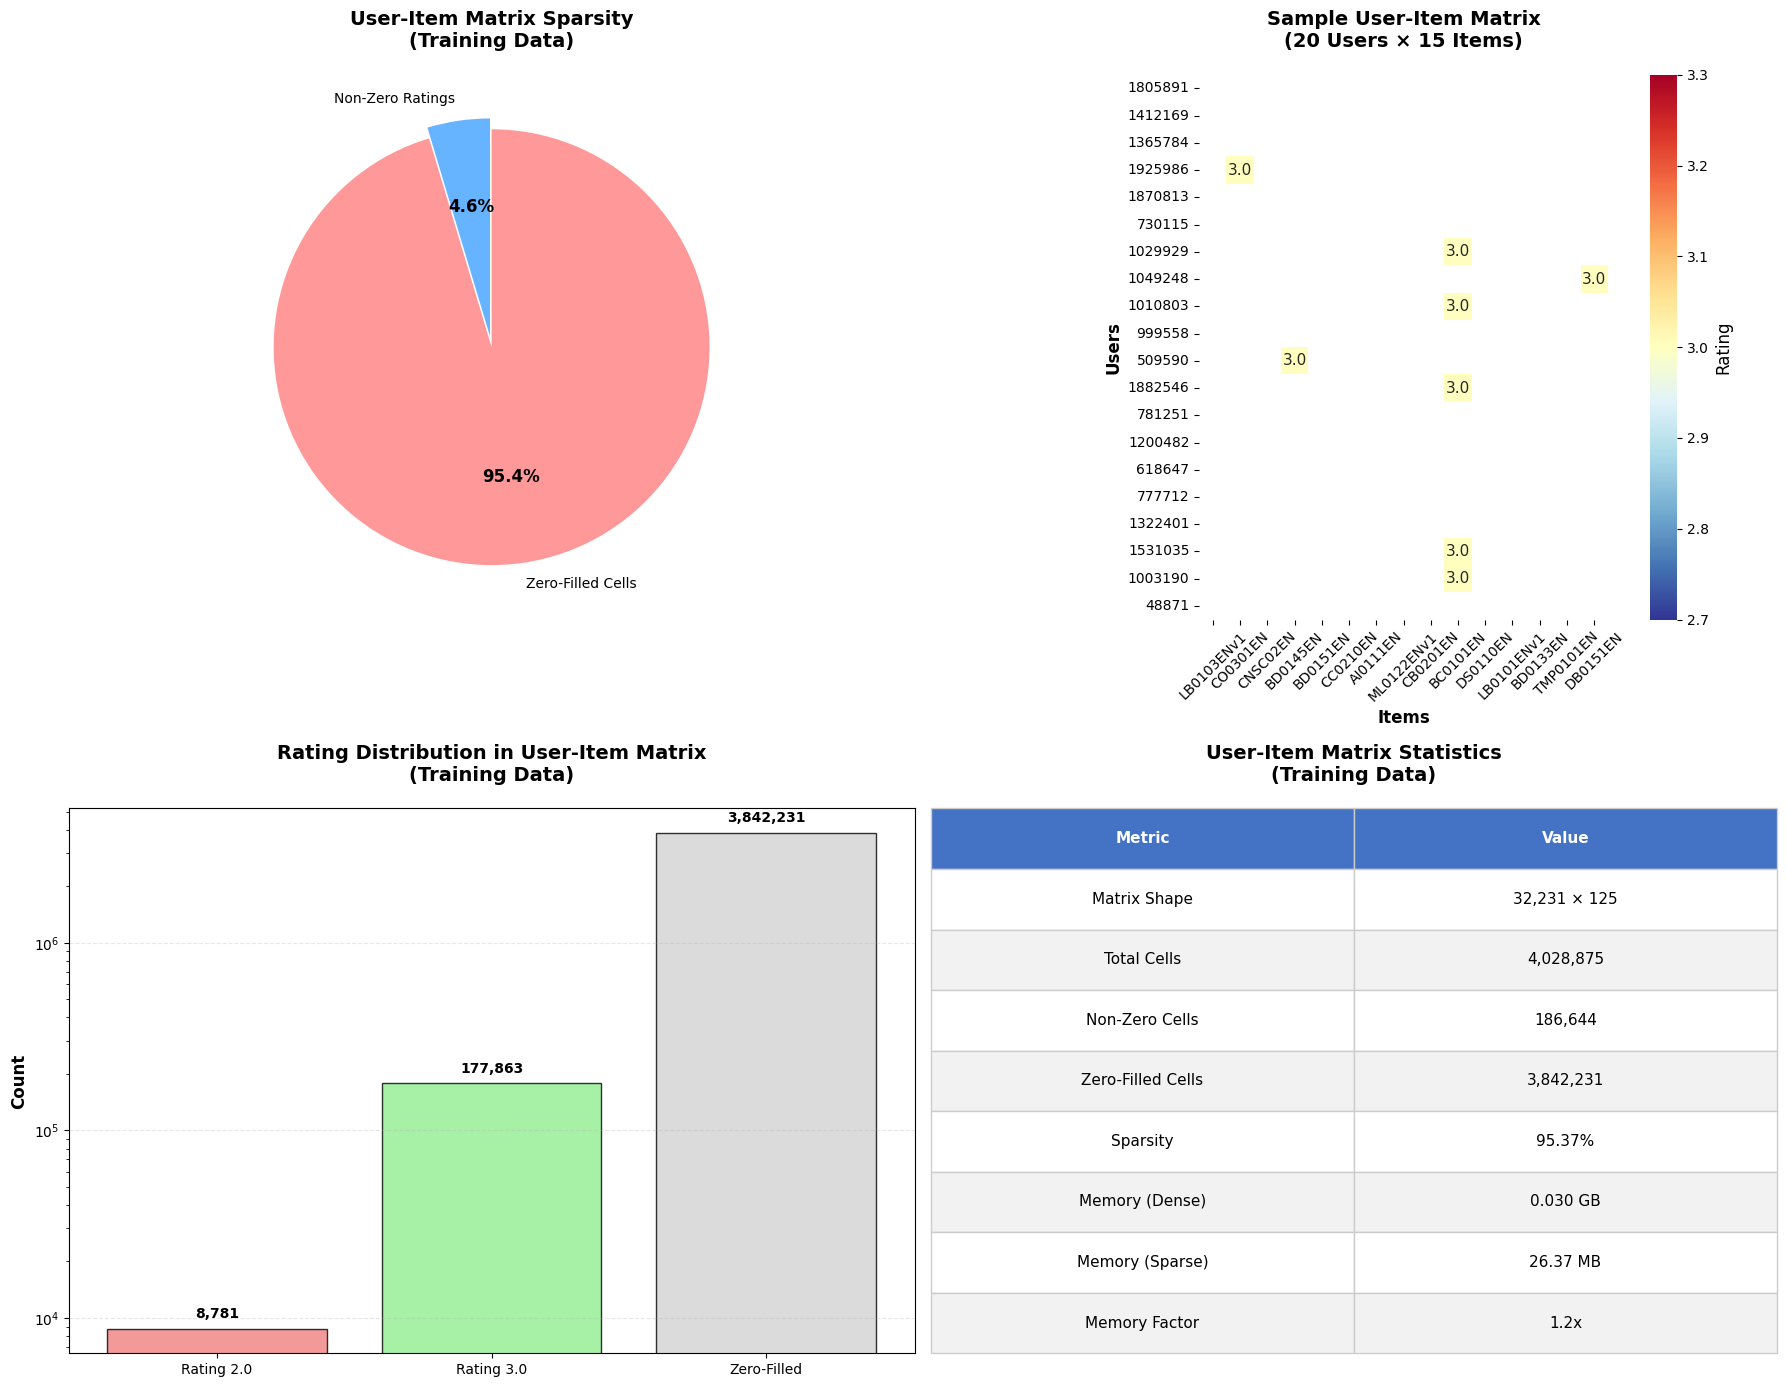


USER-ITEM MATRIX CREATION COMPLETED
KEY OBSERVATIONS:
- Matrix created with 95.37% sparsity
- Memory expansion: 1.2x from sparse to dense
- Zero-filling introduces 3,842,231 artificial 'no rating' entries
- This naive approach may bias similarity calculations toward zero values

READY FOR USER-USER SIMILARITY COMPUTATION


In [40]:
# Step 2.2: Create Training User-Item Matrix (Naive Zero-Filling)
print("=" * 80)
print("STEP 2.2: CREATE TRAINING USER-ITEM MATRIX (NAIVE ZERO-FILLING)")
print("=" * 80)

# Create user-item matrix from training data using pivot table
print("CREATING USER-ITEM MATRIX:")
train_matrix = train_df.pivot_table(index='user', columns='item', values='rating', fill_value=0)

print(f"  Matrix shape: {train_matrix.shape}")
print(f"  Total cells: {train_matrix.shape[0] * train_matrix.shape[1]:,}")
print(f"  Non-zero cells: {(train_matrix != 0).sum().sum():,}")
print(f"  Zero-filled cells: {(train_matrix == 0).sum().sum():,}")

# Calculate matrix sparsity
matrix_sparsity = (train_matrix == 0).sum().sum() / (train_matrix.shape[0] * train_matrix.shape[1])
print(f"  Matrix sparsity: {matrix_sparsity:.4f} ({matrix_sparsity*100:.2f}%)")

# Memory usage analysis
print(f"\nMEMORY USAGE ANALYSIS:")
sparse_memory_mb = train_df.memory_usage(deep=True).sum() / 1024**2
dense_memory_gb = train_matrix.memory_usage(deep=True).sum() / 1024**3
print(f"  Sparse representation (original data): {sparse_memory_mb:.2f} MB")
print(f"  Dense matrix representation: {dense_memory_gb:.4f} GB")
print(f"  Memory expansion factor: {dense_memory_gb*1024/sparse_memory_mb:.1f}x")

# Analyze rating distribution in the matrix
print(f"\nRATING DISTRIBUTION IN MATRIX:")
non_zero_ratings = train_matrix[train_matrix != 0]
rating_counts_matrix = non_zero_ratings.stack().value_counts().sort_index()

for rating, count in rating_counts_matrix.items():
    percentage = count / len(train_df) * 100
    print(f"  Rating {rating}: {count:,} ({percentage:.2f}%)")

zero_count = (train_matrix == 0).sum().sum()
print(f"  Zero-filled: {zero_count:,} ({zero_count/(train_matrix.shape[0]*train_matrix.shape[1])*100:.2f}%)")

# Sample the matrix for visualization
print(f"\nCREATING VISUALIZATION SAMPLES:")
np.random.seed(RANDOM_STATE)

# Select a random sample of users and items for visualization
sample_size_users = min(20, train_matrix.shape[0])
sample_size_items = min(15, train_matrix.shape[1])

sample_users = np.random.choice(train_matrix.index, size=sample_size_users, replace=False)
sample_items = np.random.choice(train_matrix.columns, size=sample_size_items, replace=False)

sample_matrix = train_matrix.loc[sample_users, sample_items]
print(f"  Sample matrix shape: {sample_matrix.shape}")
print(f"  Sample sparsity: {(sample_matrix == 0).sum().sum()/(sample_matrix.shape[0]*sample_matrix.shape[1]):.2f}")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# 1. Matrix Sparsity Visualization
sparsity_data = [(train_matrix != 0).sum().sum(), (train_matrix == 0).sum().sum()]
sparsity_labels = ['Non-Zero Ratings', 'Zero-Filled Cells']
colors_sparsity = ['#66b3ff', '#ff9999']

wedges, texts, autotexts = ax1.pie(sparsity_data, labels=sparsity_labels, colors=colors_sparsity,
                                   autopct='%1.1f%%', startangle=90, explode=(0.05, 0))

ax1.set_title('User-Item Matrix Sparsity\n(Training Data)', fontsize=14, fontweight='bold', pad=20)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

# 2. Sample Matrix Heatmap
mask = sample_matrix == 0
sns.heatmap(sample_matrix, mask=mask, annot=True, fmt='.1f', cmap='RdYlBu_r',
            cbar_kws={'label': 'Rating'}, ax=ax2, square=True)

ax2.set_title(f'Sample User-Item Matrix\n({sample_size_users} Users × {sample_size_items} Items)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Items', fontweight='bold')
ax2.set_ylabel('Users', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

# 3. Rating Distribution in Matrix
rating_data = [rating_counts_matrix[2.0], rating_counts_matrix[3.0], zero_count]
rating_labels = ['Rating 2.0', 'Rating 3.0', 'Zero-Filled']
colors_rating = ['lightcoral', 'lightgreen', 'lightgray']

bars_rating = ax3.bar(rating_labels, rating_data, color=colors_rating, alpha=0.8,
                      edgecolor='black', linewidth=1)

ax3.set_title('Rating Distribution in User-Item Matrix\n(Training Data)', 
              fontsize=14, fontweight='bold', pad=20)
ax3.set_ylabel('Count', fontweight='bold')
ax3.set_yscale('log')  # Log scale due to large difference between zeros and ratings
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar in bars_rating:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height * 1.1,
             f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. Matrix Statistics Summary Table
stats_data = [
    ['Matrix Shape', f'{train_matrix.shape[0]:,} × {train_matrix.shape[1]:,}'],
    ['Total Cells', f'{train_matrix.shape[0] * train_matrix.shape[1]:,}'],
    ['Non-Zero Cells', f'{(train_matrix != 0).sum().sum():,}'],
    ['Zero-Filled Cells', f'{(train_matrix == 0).sum().sum():,}'],
    ['Sparsity', f'{matrix_sparsity:.2%}'],
    ['Memory (Dense)', f'{dense_memory_gb:.3f} GB'],
    ['Memory (Sparse)', f'{sparse_memory_mb:.2f} MB'],
    ['Memory Factor', f'{dense_memory_gb*1024/sparse_memory_mb:.1f}x']
]

# Create table
ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=stats_data,
                  colLabels=['Metric', 'Value'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

# Style the table
for (i, j), cell in table.get_celld().items():
    if i == 0:  # Header row
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4472C4')
    else:
        cell.set_facecolor('#F2F2F2' if i % 2 == 0 else 'white')
    cell.set_edgecolor('#CCCCCC')
    cell.set_linewidth(1)

ax4.set_title('User-Item Matrix Statistics\n(Training Data)', 
              fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("USER-ITEM MATRIX CREATION COMPLETED")
print("=" * 80)
print("KEY OBSERVATIONS:")
print(f"- Matrix created with {matrix_sparsity:.2%} sparsity")
print(f"- Memory expansion: {dense_memory_gb*1024/sparse_memory_mb:.1f}x from sparse to dense")
print(f"- Zero-filling introduces {zero_count:,} artificial 'no rating' entries")
print(f"- This naive approach may bias similarity calculations toward zero values")
print("\nREADY FOR USER-USER SIMILARITY COMPUTATION")
print("=" * 80)

STEP 2.3: COMPUTE USER-USER COSINE SIMILARITY MATRIX
COMPUTING COSINE SIMILARITY:
  Input matrix shape: (32231, 125)
  Computing similarity between 32,231 users...
  Similarity matrix shape: (32231, 32231)
  Similarity matrix memory: 7.7399 GB

SIMILARITY STATISTICS:
  Total user pairs: 519,402,565
  Non-zero similarities: 240,446,481
  Zero similarities: 798,390,880
  Mean similarity (non-zero): 0.3019
  Median similarity (non-zero): 0.2722
  Std similarity (non-zero): 0.1507
  Min similarity: 0.0222
  Max similarity: 1.0000

SIMILARITY PERCENTILES (NON-ZERO):
  50th percentile: 0.2722
  75th percentile: 0.3858
  90th percentile: 0.5000
  95th percentile: 0.5669
  99th percentile: 0.8660

HIGH SIMILARITY ANALYSIS:
  Threshold (99th percentile): 0.8660
  Highly similar pairs: 2,428,177

SAMPLE USER SIMILARITIES:
  User 1805891 similarities:
    vs User 1412169: 0.0000
    vs User 1365784: 0.0000
    vs User 1925986: 0.0000
    vs User 1870813: 0.0000
  User 1412169 similarities:
    vs

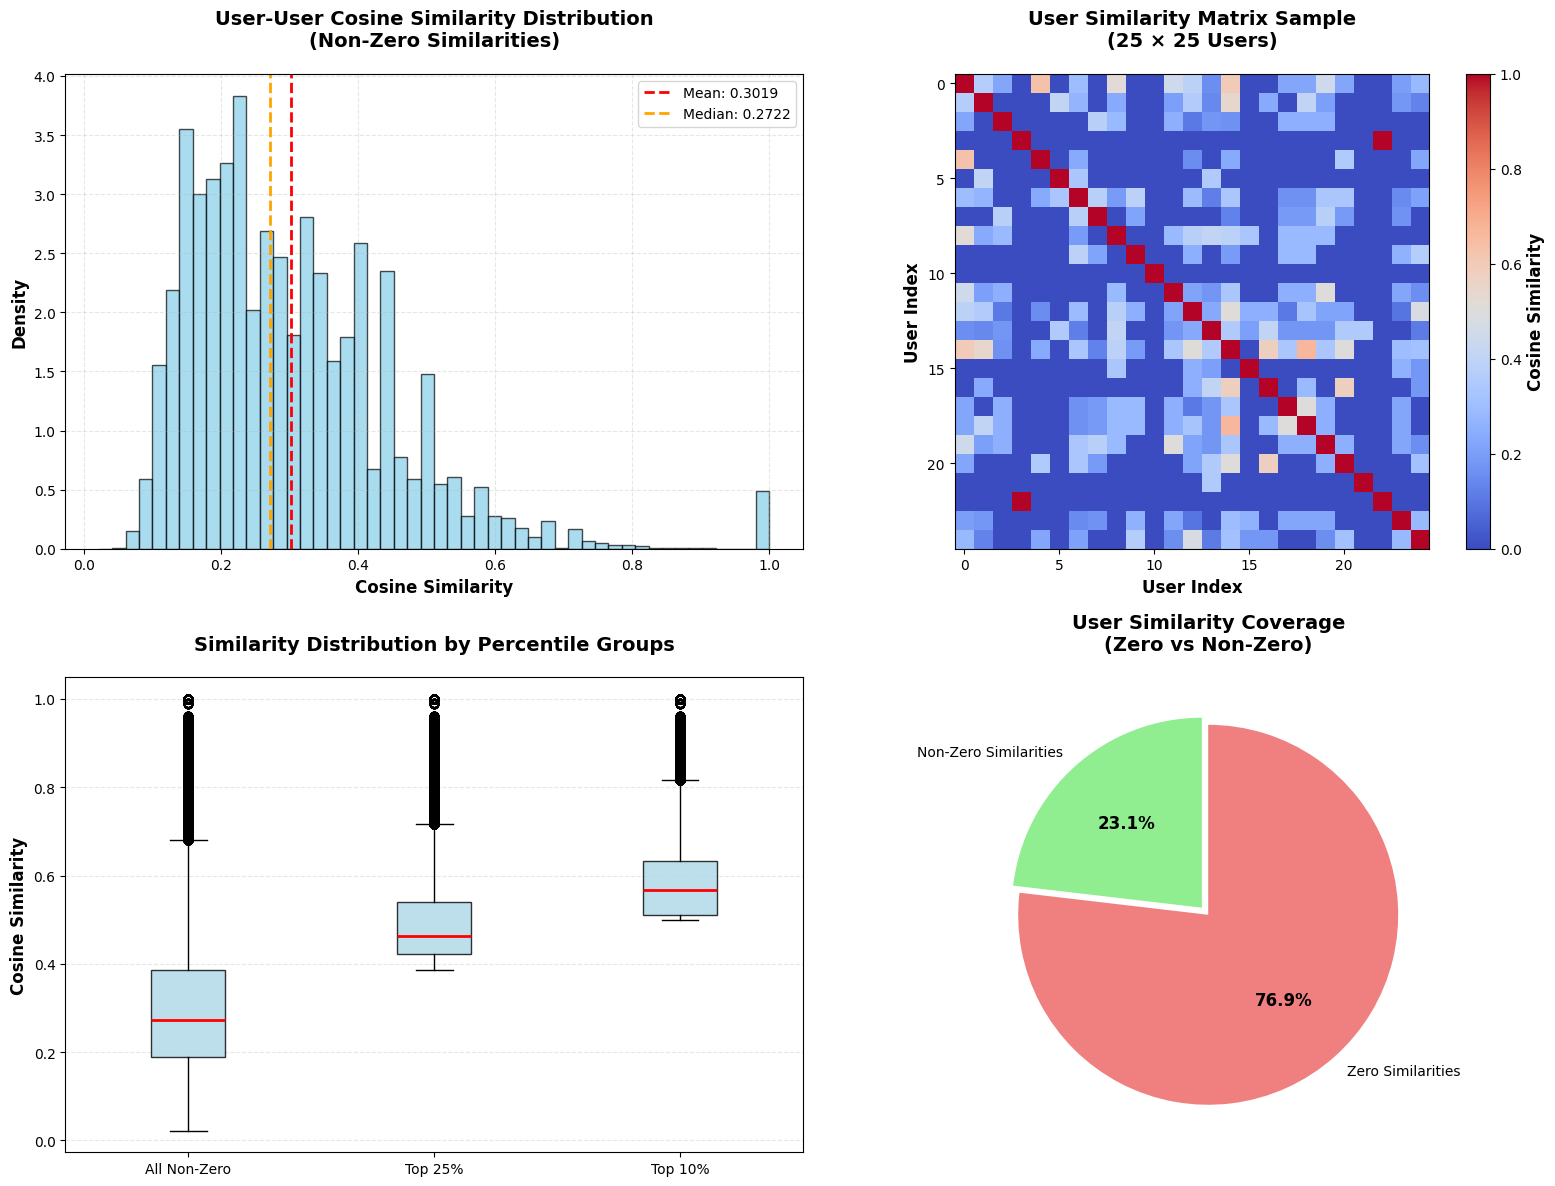


USER-USER SIMILARITY COMPUTATION COMPLETED
KEY OBSERVATIONS:
- Computed 32,231 × 32,231 similarity matrix
- 240,446,481 non-zero similarities out of 32,231 pairs
- Mean similarity: 0.3019 (relatively low due to sparsity)
- High similarity threshold (99th percentile): 0.8660
- Memory usage: 7.7399 GB

READY FOR PREDICTION FUNCTION IMPLEMENTATION


In [41]:
# Step 2.3: Compute User-User Cosine Similarity Matrix
print("=" * 80)
print("STEP 2.3: COMPUTE USER-USER COSINE SIMILARITY MATRIX")
print("=" * 80)

# Import required library for similarity computation
from sklearn.metrics.pairwise import cosine_similarity

print("COMPUTING COSINE SIMILARITY:")
print(f"  Input matrix shape: {train_matrix.shape}")
print(f"  Computing similarity between {train_matrix.shape[0]:,} users...")

# Compute cosine similarity matrix
# Note: cosine_similarity returns a symmetric matrix where element (i,j) represents 
# the cosine similarity between user i and user j
user_similarity_matrix = cosine_similarity(train_matrix)

print(f"  Similarity matrix shape: {user_similarity_matrix.shape}")
print(f"  Similarity matrix memory: {user_similarity_matrix.nbytes / 1024**3:.4f} GB")

# Analyze similarity distribution
print(f"\nSIMILARITY STATISTICS:")
# Exclude self-similarities (diagonal) for meaningful statistics
upper_triangle = np.triu(user_similarity_matrix, k=1)  # k=1 excludes diagonal
non_zero_similarities = upper_triangle[upper_triangle > 0]

print(f"  Total user pairs: {(train_matrix.shape[0] * (train_matrix.shape[0] - 1)) // 2:,}")
print(f"  Non-zero similarities: {len(non_zero_similarities):,}")
print(f"  Zero similarities: {len(upper_triangle[upper_triangle == 0]):,}")
print(f"  Mean similarity (non-zero): {non_zero_similarities.mean():.4f}")
print(f"  Median similarity (non-zero): {np.median(non_zero_similarities):.4f}")
print(f"  Std similarity (non-zero): {non_zero_similarities.std():.4f}")
print(f"  Min similarity: {non_zero_similarities.min():.4f}")
print(f"  Max similarity: {non_zero_similarities.max():.4f}")

# Analyze similarity distribution percentiles
percentiles = [50, 75, 90, 95, 99]
print(f"\nSIMILARITY PERCENTILES (NON-ZERO):")
for p in percentiles:
    value = np.percentile(non_zero_similarities, p)
    print(f"  {p}th percentile: {value:.4f}")

# Find highly similar user pairs (top 1%)
high_similarity_threshold = np.percentile(non_zero_similarities, 99)
high_similarity_pairs = np.where(upper_triangle >= high_similarity_threshold)
print(f"\nHIGH SIMILARITY ANALYSIS:")
print(f"  Threshold (99th percentile): {high_similarity_threshold:.4f}")
print(f"  Highly similar pairs: {len(high_similarity_pairs[0]):,}")

# Sample some user similarities for inspection
print(f"\nSAMPLE USER SIMILARITIES:")
np.random.seed(RANDOM_STATE)
sample_users = np.random.choice(train_matrix.index, size=min(5, len(train_matrix.index)), replace=False)

for i, user1 in enumerate(sample_users):
    user1_idx = list(train_matrix.index).index(user1)
    print(f"  User {user1} similarities:")
    
    # Get similarities with other sample users
    for j, user2 in enumerate(sample_users):
        if i != j:
            user2_idx = list(train_matrix.index).index(user2)
            similarity = user_similarity_matrix[user1_idx, user2_idx]
            print(f"    vs User {user2}: {similarity:.4f}")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Similarity Distribution Histogram
ax1.hist(non_zero_similarities, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
ax1.axvline(non_zero_similarities.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_zero_similarities.mean():.4f}')
ax1.axvline(np.median(non_zero_similarities), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(non_zero_similarities):.4f}')

ax1.set_title('User-User Cosine Similarity Distribution\n(Non-Zero Similarities)', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Cosine Similarity', fontweight='bold')
ax1.set_ylabel('Density', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, linestyle='--')

# 2. Similarity Matrix Heatmap (Sample)
# Select a small sample for visualization
sample_size = min(25, train_matrix.shape[0])
sample_indices = np.random.choice(range(train_matrix.shape[0]), size=sample_size, replace=False)
sample_similarity = user_similarity_matrix[np.ix_(sample_indices, sample_indices)]

im = ax2.imshow(sample_similarity, cmap='coolwarm', vmin=0, vmax=1)
ax2.set_title(f'User Similarity Matrix Sample\n({sample_size} × {sample_size} Users)', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('User Index', fontweight='bold')
ax2.set_ylabel('User Index', fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Cosine Similarity', fontweight='bold')

# 3. Similarity Statistics Box Plot
similarity_data = [
    non_zero_similarities,
    non_zero_similarities[non_zero_similarities >= np.percentile(non_zero_similarities, 75)],
    non_zero_similarities[non_zero_similarities >= np.percentile(non_zero_similarities, 90)]
]
labels = ['All Non-Zero', 'Top 25%', 'Top 10%']

box_plot = ax3.boxplot(similarity_data, labels=labels, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.8),
                       medianprops=dict(color='red', linewidth=2))

ax3.set_title('Similarity Distribution by Percentile Groups', fontsize=14, fontweight='bold', pad=20)
ax3.set_ylabel('Cosine Similarity', fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# 4. Zero vs Non-Zero Similarity Pie Chart
zero_count = len(upper_triangle[upper_triangle == 0])
non_zero_count = len(non_zero_similarities)
similarity_coverage = [non_zero_count, zero_count]
coverage_labels = ['Non-Zero Similarities', 'Zero Similarities']
colors_coverage = ['lightgreen', 'lightcoral']

wedges, texts, autotexts = ax4.pie(similarity_coverage, labels=coverage_labels, colors=colors_coverage,
                                   autopct='%1.1f%%', startangle=90, explode=(0.05, 0))

ax4.set_title('User Similarity Coverage\n(Zero vs Non-Zero)', fontsize=14, fontweight='bold', pad=20)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.show()

# Convert similarity matrix to DataFrame for easier access
user_similarity_df = pd.DataFrame(user_similarity_matrix, 
                                  index=train_matrix.index, 
                                  columns=train_matrix.index)

print("\n" + "=" * 80)
print("USER-USER SIMILARITY COMPUTATION COMPLETED")
print("=" * 80)
print("KEY OBSERVATIONS:")
print(f"- Computed {user_similarity_matrix.shape[0]:,} × {user_similarity_matrix.shape[1]:,} similarity matrix")
print(f"- {len(non_zero_similarities):,} non-zero similarities out of {len(upper_triangle):,} pairs")
print(f"- Mean similarity: {non_zero_similarities.mean():.4f} (relatively low due to sparsity)")
print(f"- High similarity threshold (99th percentile): {high_similarity_threshold:.4f}")
print(f"- Memory usage: {user_similarity_matrix.nbytes / 1024**3:.4f} GB")
print("\nREADY FOR PREDICTION FUNCTION IMPLEMENTATION")
print("=" * 80)

In [ ]:
# Step 2.4: Define Baseline Prediction Function
print("=" * 80)
print("STEP 2.4: DEFINE BASELINE PREDICTION FUNCTION")
print("=" * 80)

def predict_rating(user_id, item_id, k=10):
    """
    Predict rating for a user-item pair using k-nearest neighbors collaborative filtering.
    
    Parameters:
    - user_id: ID of the user for whom to predict
    - item_id: ID of the item to predict rating for
    - k: Number of nearest neighbors to consider
    
    Returns:
    - predicted_rating: Predicted rating (float)
    """
    # Check if user or item exists in training data
    if user_id not in train_matrix.index:
        return df['rating'].mean()  # Return global average for cold start users
    
    if item_id not in train_matrix.columns:
        return df['rating'].mean()  # Return global average for cold start items
    
    # Get user index in the matrix
    user_idx = list(train_matrix.index).index(user_id)
    
    # Get similarities for this user with all other users
    user_similarities = user_similarity_matrix[user_idx]
    
    # Get ratings for the target item from all users
    item_ratings = train_matrix[item_id]
    
    # Find users who have rated the target item (non-zero ratings)
    rated_users = item_ratings[item_ratings > 0]
    
    if len(rated_users) == 0:
        return df['rating'].mean()  # No users have rated this item
    
    # Get similarities only for users who have rated the item
    relevant_similarities = []
    relevant_ratings = []
    
    for rated_user_id in rated_users.index:
        rated_user_idx = list(train_matrix.index).index(rated_user_id)
        similarity = user_similarities[rated_user_idx]
        
        # Only consider users with positive similarity
        if similarity > 0:
            relevant_similarities.append(similarity)
            relevant_ratings.append(rated_users[rated_user_id])
    
    if len(relevant_similarities) == 0:
        return df['rating'].mean()  # No similar users found
    
    # Convert to numpy arrays for easier manipulation
    similarities = np.array(relevant_similarities)
    ratings = np.array(relevant_ratings)
    
    # Select top-k most similar users
    if len(similarities) > k:
        top_k_indices = np.argsort(similarities)[-k:]
        similarities = similarities[top_k_indices]
        ratings = ratings[top_k_indices]
    
    # Calculate weighted average
    if np.sum(similarities) > 0:
        predicted_rating = np.sum(similarities * ratings) / np.sum(similarities)
    else:
        predicted_rating = df['rating'].mean()
    
    return predicted_rating

# Test the prediction function with sample cases
print("TESTING PREDICTION FUNCTION:")

# Test case 1: Existing user-item pair
test_cases = []
sample_test_data = test_df.sample(5, random_state=RANDOM_STATE)

for idx, row in sample_test_data.iterrows():
    user_id = row['user']
    item_id = row['item']
    actual_rating = row['rating']
    
    predicted_rating = predict_rating(user_id, item_id, k=10)
    error = abs(predicted_rating - actual_rating)
    
    test_cases.append({
        'user_id': user_id,
        'item_id': item_id,
        'actual': actual_rating,
        'predicted': predicted_rating,
        'error': error
    })
    
    print(f"  User {user_id}, Item {item_id}:")
    print(f"    Actual: {actual_rating:.2f}, Predicted: {predicted_rating:.2f}, Error: {error:.2f}")

# Calculate average error for sample
avg_error = np.mean([case['error'] for case in test_cases])
print(f"\nSample average error: {avg_error:.4f}")

# Test with different k values on a small subset
print(f"\nTESTING DIFFERENT K VALUES:")
k_values = [1, 5, 10, 20, 30]
k_performance = {}

# Use a small subset for k testing (to save computation time)
test_subset = test_df.sample(100, random_state=RANDOM_STATE)

for k in k_values:
    errors = []
    print(f"  Testing k={k}...")
    
    for idx, row in test_subset.iterrows():
        user_id = row['user']
        item_id = row['item']
        actual_rating = row['rating']
        
        predicted_rating = predict_rating(user_id, item_id, k=k)
        error = abs(predicted_rating - actual_rating)
        errors.append(error)
    
    avg_error = np.mean(errors)
    rmse = np.sqrt(np.mean([(pred - actual)**2 for pred, actual in 
                            zip([predict_rating(row['user'], row['item'], k) for _, row in test_subset.iterrows()],
                                test_subset['rating'])]))
    
    k_performance[k] = {'mae': avg_error, 'rmse': rmse}
    print(f"    MAE: {avg_error:.4f}, RMSE: {rmse:.4f}")

# Create visualization of prediction function performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sample Predictions vs Actual
actual_values = [case['actual'] for case in test_cases]
predicted_values = [case['predicted'] for case in test_cases]

ax1.scatter(actual_values, predicted_values, alpha=0.7, s=100, color='steelblue', edgecolors='black')
ax1.plot([2, 3], [2, 3], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Rating', fontweight='bold')
ax1.set_ylabel('Predicted Rating', fontweight='bold')
ax1.set_title('Sample Predictions vs Actual Ratings\n(5 Test Cases)', fontsize=14, fontweight='bold', pad=20)
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xlim(1.8, 3.2)
ax1.set_ylim(1.8, 3.2)

# Add case labels
for i, case in enumerate(test_cases):
    ax1.annotate(f'Case {i+1}', (case['actual'], case['predicted']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# 2. K-Value Performance Comparison
k_vals = list(k_performance.keys())
mae_vals = [k_performance[k]['mae'] for k in k_vals]
rmse_vals = [k_performance[k]['rmse'] for k in k_vals]

ax2.plot(k_vals, mae_vals, 'o-', linewidth=2, markersize=8, label='MAE', color='blue')
ax2.plot(k_vals, rmse_vals, 's-', linewidth=2, markersize=8, label='RMSE', color='red')
ax2.set_xlabel('Number of Neighbors (k)', fontweight='bold')
ax2.set_ylabel('Error', fontweight='bold')
ax2.set_title('Performance vs K-Value\n(100 Test Cases)', fontsize=14, fontweight='bold', pad=20)
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xticks(k_vals)

# Add value labels
for i, k in enumerate(k_vals):
    ax2.annotate(f'{mae_vals[i]:.3f}', (k, mae_vals[i]), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)
    ax2.annotate(f'{rmse_vals[i]:.3f}', (k, rmse_vals[i]), textcoords="offset points", 
                xytext=(0,-15), ha='center', fontsize=9)

# 3. Error Distribution
all_errors = [case['error'] for case in test_cases]
ax3.hist(all_errors, bins=10, alpha=0.7, color='lightcoral', edgecolor='black')
ax3.axvline(np.mean(all_errors), color='red', linestyle='--', linewidth=2, 
           label=f'Mean Error: {np.mean(all_errors):.3f}')
ax3.set_xlabel('Absolute Error', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Error Distribution\n(5 Sample Cases)', fontsize=14, fontweight='bold', pad=20)
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Prediction Function Algorithm Flowchart (Text-based)
flowchart_text = [
    "BASELINE PREDICTION ALGORITHM",
    "",
    "1. Input: user_id, item_id, k",
    "",
    "2. Check if user/item in training data",
    "   → If not: return global average",
    "",
    "3. Get user similarities from matrix",
    "",
    "4. Find users who rated target item",
    "   → If none: return global average",
    "",
    "5. Filter by positive similarity",
    "   → If none: return global average",
    "",
    "6. Select top-k similar users",
    "",
    "7. Compute weighted average:",
    "   prediction = Σ(similarity × rating) / Σ(similarity)",
    "",
    "8. Return predicted rating"
]

ax4.text(0.05, 0.95, '\n'.join(flowchart_text), transform=ax4.transAxes, 
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor='lightblue', alpha=0.8))
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("BASELINE PREDICTION FUNCTION IMPLEMENTED")
print("=" * 80)
print("FUNCTION CHARACTERISTICS:")
print(f"- Uses top-k nearest neighbors approach")
print(f"- Handles cold start with global average fallback")
print(f"- Requires positive similarity for consideration")
print(f"- Applies weighted average based on similarity scores")
print(f"- Sample performance: MAE = {avg_error:.4f}")
print("\nREADY FOR COMPREHENSIVE HYPERPARAMETER TUNING")
print("=" * 80)

STEP 2.4: DEFINE BASELINE PREDICTION FUNCTION
TESTING PREDICTION FUNCTION:
  User 969644, Item RP0105EN:
    Actual: 3.00, Predicted: 3.00, Error: 0.00
  User 1094498, Item DV0151EN:
    Actual: 3.00, Predicted: 3.00, Error: 0.00
  User 986709, Item DA0101EN:
    Actual: 3.00, Predicted: 3.00, Error: 0.00
  User 1132086, Item DS0301EN:
    Actual: 3.00, Predicted: 3.00, Error: 0.00
  User 1254997, Item LB0101ENv1:
    Actual: 3.00, Predicted: 3.00, Error: 0.00

Sample average error: 0.0000

TESTING DIFFERENT K VALUES:
  Testing k=1...
